## **AI for Epigraphy: Ανάλυση Εικόνων και Κειμένων Αρχαίων Ελληνικών Επιγραφών**

**Εφαρμοσμένη Επιστήμη Δεδομένων — Ομαδική Εργασία 2026**

Σε αυτή την εργασία θα σχεδιάσετε ένα πλήρες υπολογιστικό pipeline για την ανάλυση αρχαίων ελληνικών επιγραφών. Το σύνολο δεδομένων αποτελεί μέρος του ICDAR 2026 Competition in Text Recognition on Greek Squeezes και είναι διαθέσιμο [εδώ](https://www.science.smith.edu/~nhowe/contest/trogs26.html#dataset).

Τα δεδομένα περιλαμβάνουν μεταγραφές κειμένων (λατινικοί χαρακτήρες σε μορφή scriptio continua) και εικόνες επιγραφών (squeezes).

Πρόκειται για εργασία 2 ατόμων. Καλείστε να απαντήσετε και στα δύο μέρη (Α και Β). Η συμμετοχή στο ICDAR Competition είναι προαιρετική (+10% στον βαθμό της εργασίας). Αν βρεθείτε στους top-20 του διαγωνισμού: +10% στον τελικό βαθμό του μαθήματος.

Παραδοτέα:
1. Αρχεία κώδικα (ipynb/py) με ονομασία <ΑΜ1>_<ΑΜ2>
2. Αναφορά 5-6 σελίδων σε PDF
3. prompts_<ΑΜ1>_<ΑΜ2>.md (υποχρεωτικό)
4. Προαιρετικό: μονοσέλιδο ICDAR competition document

---

| | |
|---|---|
| **Μέλος 1** | [Θεόδωρος Τσιρικόλιας], ΑΜ: [3220215] |
| **Μέλος 2** | [Γεώργιος Παπαθεοδώρου], ΑΜ: [3220152] |
| **Μέλος 2** | [Στυλιανή Μουμτζή], ΑΜ: [3220127] |

**Συνεισφορά μελών:**
- Μέλος 1: [Β1,Β2,Β3,λίγο από Α2 και Α3]
- Μέλος 2: [Α6,Α1, λίγο από Α2 και λίγο Α3]
- Μέλος 3: [Α4,Α5]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import numpy as np
from collections import Counter
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
import seaborn as sns



c:\Users\dodor\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
proxies={'A': 'Α', 'B': 'Β', 'G': 'Γ', 'D': 'Δ', 'E': 'Ε',
        'Z': 'Ζ', 'H': 'Η', 'Q': 'Θ', 'I': 'Ι', 'K': 'Κ',
        'L': 'Λ', 'M': 'Μ', 'N': 'Ν', 'X': 'Ξ', 'O': 'Ο',
        'P': 'Π', 'R': 'Ρ', 'S': 'Σ', 'T': 'Τ', 'Y': 'Υ',
        'F': 'Φ', 'C': 'Χ','U': 'Ψ','W': 'Ω', ':' : ':',')' : ')',
        '&' : '&','*':'*'}

path = "" #insert path here

def transcriptchange(path,proxies):
    before_count = 0
    results = {}
    files = [f for f in os.listdir(path) if f.endswith('.txt')]
    for filename in files:
        file_path = os.path.join(path, filename)
        transcript_lines = []
        latin_line = []
        is_transcript_section = False
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line.startswith("# Transcript"):
                    is_transcript_section = True
                    continue
                if line.startswith("# Lines"):
                    is_transcript_section = False
                    break
                if is_transcript_section and line:
                    latin_line.append(line)
                    greek_line = "".join([proxies.get(char, char) for char in line])
                    transcript_lines.append(greek_line)

        if before_count <=5: # Print the first 5 files for verification
            print("File: ", filename)
            print("Transcription before: ", ''.join(latin_line))
            print('Transcription after ', ''.join(transcript_lines))
            before_count += 1
        results[filename] = ''.join(transcript_lines)

    return results

annotations_results = transcriptchange(path, proxies)
df = pd.DataFrame(annotations_results.items(), columns=['File Name', 'Greek Transcription'])
listpros=[df['Greek Transcription'].iloc[i] for i in range(len(df))]

                         

                    
        

File:  Agora_I_4985_Rotation1_300dpi_letters.txt
Transcription before:  STOKAI*DIKOSE*IHIDIKHTOSENNEA*AYTOID*NEANTISASIASEANT*ODONAIEA*NPOLEWSAPNIOSAQHN*AIPROS*ILIONM*AF*
Transcription after  ΣΤΟΚΑΙ*ΔΙΚΟΣΕ*ΙΗΙΔΙΚΗΤΟΣΕΝΝΕΑ*ΑΥΤΟΙΔ*ΝΕΑΝΤΙΣΑΣΙΑΣΕΑΝΤ*ΟΔΟΝΑΙΕΑ*ΝΠΟΛΕΩΣΑΠΝΙΟΣΑΘΗΝ*ΑΙΠΡΟΣ*ΙΛΙΟΝΜ*ΑΦ*
File:  Agora_I_4985_Rotation2_300dpi_letters.txt
Transcription before:  STOKAI*DIKOSE*IHIDIKHTOSENNEA*AYTOID*NEANTISASIASEANT*ODONAIEA*NPOLEWSAPNIOSAQHN*AIPROS*ILIONM*AF*
Transcription after  ΣΤΟΚΑΙ*ΔΙΚΟΣΕ*ΙΗΙΔΙΚΗΤΟΣΕΝΝΕΑ*ΑΥΤΟΙΔ*ΝΕΑΝΤΙΣΑΣΙΑΣΕΑΝΤ*ΟΔΟΝΑΙΕΑ*ΝΠΟΛΕΩΣΑΠΝΙΟΣΑΘΗΝ*ΑΙΠΡΟΣ*ΙΛΙΟΝΜ*ΑΦ*
File:  Agora_I_5477_Rotation1_300dpi_letters.txt
Transcription before:  RCONTOS*RISTONIKOS ARI*N***HI AGAQHI TOY DHMO*AQHNAI H QYSIA WS KALLISTIKROIS KAI PROSODOS WS PLE**S DEDOCQAI TOIS NOMOQET*AN DEK* *MERAIS PROTERON NA ETH KATA DIKLHRIAN TWI TO POTERWI ETEI H WI AN H DASQWTAI* EGGYHTAS LAMBANO** *ENTHKOSTHN PWLEIN THN EN T** TOYS DE PRYTANEIS PROGRAFEIN MISQWSIN THS NEAS D*ARRHDHNTHN PRASIN THS EN THI NEAI CWRI

Το transliteration system που χρησιμοποιήθηκε είναι 1-1 αντιστοίχηση των λατινικών χαρακατήρψν με τους αντίστοιχους ελληνικούς. Τα ειδικά σύμβολα διατηρήθηκαν ως έχει. Η αντιστοιχία έγινε όπως ορίζεται από το αρχείο proxies. 

In [3]:
dataset = load_dataset("Ericu950/Papyri_1", split="train", streaming=True)

vocabulary = Counter()

def clean_text(text):
    return text.isalpha()

for record in dataset:
    text = record['Edition_with_brackets'].upper().split()
    text_cleaned = filter(clean_text, text)
    for word in text_cleaned:
        vocabulary[word] += 1
    

def text_segmentation(text, vocabulary, max_segment):
    words = []
    i=0 
    
    while i<len(text):
        if not text[i].isalpha():   #if symbol is found move index forward
            words.append(text[i])
            i += 1
            continue 
        matched = False
        for j in range(min(i + max_segment, len(text)),i,-1):  #from longest to shortest segment
            candidate = text[i:j]

            if candidate in vocabulary:
                words.append(candidate)
                i=j
                matched = True
                break
        
        if not matched:
            words.append(text[i])
            i+=1

    return ' '.join(words)


df['Greek Transcription'] = df['Greek Transcription'].apply(lambda x: text_segmentation(x, vocabulary, 15))

Ως μέθοδο για την τμηματοποίηση του scriptio continua format, χρησιμοποιήθηκε greedy αλγόριθμος. Δηλαδή έχοντας δημιουργήσει ένα λεξιλόγιο πρωτίστως, ξεκινώντας από την αρχή ενός πάπυρου, και έχοντας ένα άνω φράγμα για το μέγεθος της λέξης, ελέγχουμε κάθε φορά αν το τμήμα που έχουμε ταιριάζει με μια λέξη του λεξιλογίου, ξεκινόντας από το μέγιστο μέγεθος και μειώνοντας το μέγεθος του τμήματος κατά ένα κάθε φορά. Αν βρούμε λέξη που ταιριάζει, προχωράμε το Index στο τέλος της. Το πρόβλημα με αυτήν την προσέγγιση είναι ότι πολλές λέξεις είναι ελλιπείς καθώς περιέχουν μη αναγνώσιμους χαρακτήρες και επομένως δεν θα μπορέσουν να ταιριαχτούν με κάποια λέξη του λεξιλογίου, καθώς περιέχει μόνο ολόκληρες. 

Το συνολικό μέγεθος του λεξιλογίου είναι: 134737

Οι 20 πιο συχνές λέξεις:
ΚΑΙ: 137634
ΤΟΥ: 76132
ΤΗΣ: 38137
ΕΤΟΥΣ: 33466
ΤΩΝ: 31355
ΔΡΑΧΜΑΙ: 25887
ΕΝ: 25556
ΔΙΑ: 25492
ΑΠΟ: 25447
ΕΙΣ: 24295
ΤΟ: 23095
ΤΗΝ: 21967
ΓΙΝΟΝΤΑΙ: 20246
ΠΑΡΑ: 19819
ΥΠΕΡ: 19657
ΔΕ: 17212
ΠΥΡΟΥ: 16375
ΔΡΑΧΜΑΣ: 16084
ΤΩ: 15684
ΤΑ: 14422

Οι 20 πιο σπάνιες λέξεις:
ΦΑΜΟΥΛΗΣ: 1
ΠΛΗΡΩΝΩ: 1
ΑΡΚΟΝΝΗΣΙΟΣ: 1
ΑΡΑΥΦΙΟΣ: 1
ΕΥΤΡΟΠΙΑ: 1
ΠΕΤΩΤΑ: 1
ΣΩΖΟΥ: 1
ΑΤΙΜΗΤΕ: 1
ΚΑΤΑΦΕΡΟΜΕΝΟΙΣ: 1
ΚΑΤΑΦΕΡΟΜΕΝΩΝ: 1
ΥΠΕΡΤΕΘΗΝΑΙ: 1
ΨΗΦΙΣΑΣΘΕ: 1
ΠΛΕΟΜΙΣΘΙΑΝ: 1
ΟΘΟΝΗΝ: 1
ΠΡΟΣΕΝΕΓΚΟΥΜΕΝ: 1
ΕΞΩΔΙΑΖΟΜΕΝΟΝ: 1
ΑΡΚΕΙΣΘΩΣΑΝ: 1
ΠΡΟΕΒΑΛΟΝΤΟ: 1
ΚΛΩΘΕΙΝ: 1
ΜΕΤΑΧΕΙΡΙΣΑΜΕΝΟΥΣ: 1


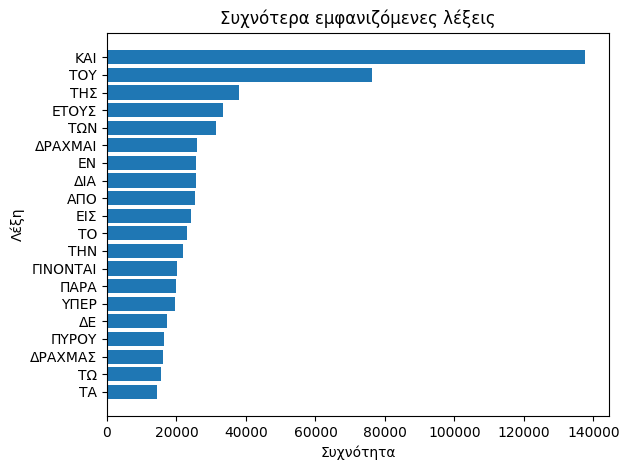

In [4]:
vocabulary_size = len(vocabulary)
print(f"Το συνολικό μέγεθος του λεξιλογίου είναι: {vocabulary_size}\n")

print("Οι 20 πιο συχνές λέξεις:")
for word, count in vocabulary.most_common(20):
    print(f"{word}: {count}")

least_common = vocabulary.most_common()[::-1]
print("\nΟι 20 πιο σπάνιες λέξεις:")
for word, count in least_common[:20]:
    print(f"{word}: {count}")

words, counts = zip(*vocabulary.most_common(20))
words = words[::-1]
counts = counts[::-1]
plt.xlabel("Συχνότητα")
plt.ylabel("Λέξη")
plt.title("Συχνότερα εμφανιζόμενες λέξεις")
plt.barh(words, counts)
plt.tight_layout()
plt.show()



<BarContainer object of 20 artists>

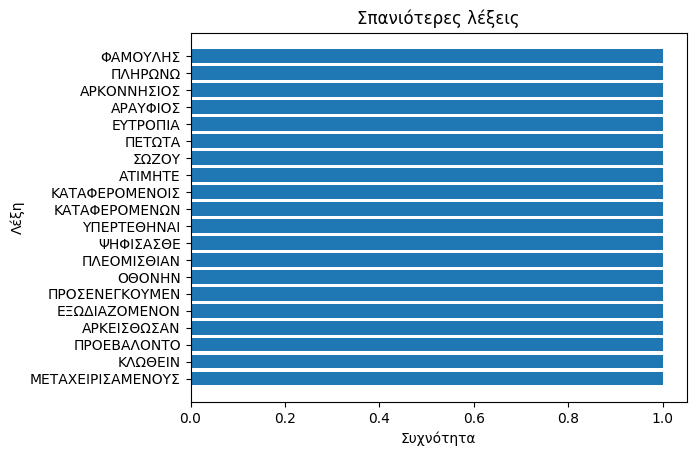

In [5]:

words,counts=zip(*least_common[:20])
words = words[::-1]
counts = counts[::-1]
plt.xlabel("Συχνότητα")
plt.ylabel("Λέξη")
plt.title("Σπανιότερες λέξεις")
plt.barh(words, counts)


### Α4. Κύρια Ονόματα
'Υστερα από αποτυχημένες προσπάθειες με χρήση cltk και κάποιες άλλες εναλλακτικές(βλ. report) αποφασίσαμε πως ο κατάλληλος τρόπος είναι αυτός της χειροκίνητης αναζήτης ονομάτων. Έτσι, δημιουργήσαμε ένα απλό λεξικό με τα πιο γνωστά αρχαία ονόματα. Ύστερα, χρησιμοποιήσαμε των κώδικα στα σχόλια για να το εμπλουτίσουμε με ονόματα που δεν είχαμε λάβει υπόψη. Συγκεκριμένα, εμφανίσαμε τις λέξεις που έχουν καταλήξεις αρχαίων ονομάτων και χειροκίνητα επιλέξαμε και περάσαμε στο λεξιλόγιο αυτές που ήταν όντως ονόματα. Το καλό με αυτό τον τρόπο είναι πως δεν υπάρχει καθόλου θόρυβος ενώ τα χαμένα ονόματα μπορούν να περιοριστούν κατά πολύ μεγάλο ποσοστό με σωστή αναζήτηση καταλήξεων και προσεκτική επιλογή των ονομάτων. Ωστόσο, απαιτείται η γνώση των αρχαίων ονομάτων ή η αναζήτηση αυτών σε λεξικά στο διαδίκτυο έτσι ώστε να μπορούμε να τα ξεχωρίσουμε από τους θορύβους. Επίσης, θα υπάρχουν ονόματα με διαφορετικές απο τις συνηθισμένες καταλήξεις τα οποία δεν μπορούμε να συλλέξουμε εαν δεν κάνουμε την αναζήτηση μας εξονυχιστική. Αυτός ο τρόπος σίγουρα δεν ήταν ο ιδανικός αλλά περισσότερες λεπτομέρειες υπάρχουν στην αναφορά.

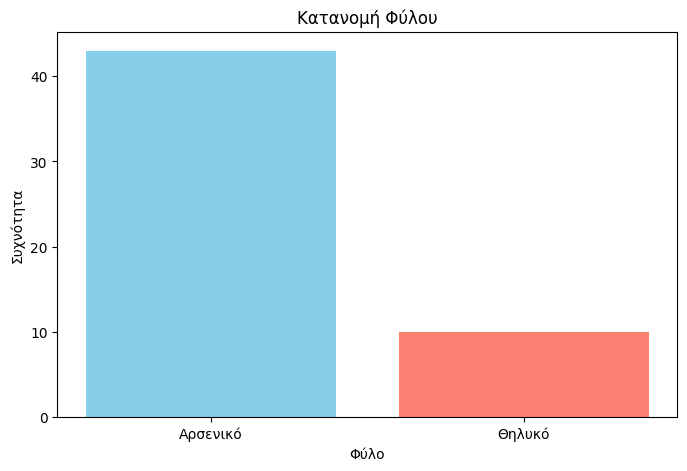

Αρσενικό: 43 (81.1%)
Θηλυκό: 10 (18.9%)


In [6]:
# Manual list of ancient names
ancient_names_dataset = {
    'ΑΓΑΜΕΜΝΩΝ': 'Αρσενικό', 'ΑΓΑΜΕΜΝΩΝΟΣ': 'Αρσενικό',
    'ΑΔΩΝΙΣ': 'Αρσενικό', 'ΑΔΩΝΙΟΥ': 'Αρσενικό',
    'ΑΙΣΧΥΛΟΣ': 'Αρσενικό', 'ΑΙΣΧΥΛΟΥ': 'Αρσενικό',
    'ΑΙΑΝΤΑΣ': 'Αρσενικό', 'ΑΙΑΝΤΟΣ': 'Αρσενικό',
    'ΑΛΕΞΑΝΔΡΟΣ': 'Αρσενικό', 'ΑΛΕΞΑΝΔΡΟΥ': 'Αρσενικό',
    'ΑΛΚΙΒΙΑΔΗΣ': 'Αρσενικό', 'ΑΛΚΙΒΙΑΔΟΥ': 'Αρσενικό',
    'ΑΓΑΘΟΚΛΗΣ': 'Αρσενικό', 'ΑΓΑΘΟΚΛΕΟΥΣ': 'Αρσενικό',
    'ΑΠΟΛΛΩΝ': 'Αρσενικό', 'ΑΠΟΛΛΩΝΟΣ': 'Αρσενικό',
    'ΖΕΥΣ': 'Αρσενικό', 'ΔΙΟΣ': 'Αρσενικό',
    'ΔΙΑΣ': 'Αρσενικό',
    'ΑΡΗΣ': 'Αρσενικό', 'ΑΡΕΩΣ': 'Αρσενικό',
    'ΑΡΙΣΤΟΤΕΛΗΣ': 'Αρσενικό', 'ΑΡΙΣΤΟΤΕΛΟΥΣ': 'Αρσενικό',
    'ΑΡΙΣΤΕΙΔΗΣ': 'Αρσενικό', 'ΑΡΙΣΤΕΙΔΟΥΣ': 'Αρσενικό',
    'ΑΧΙΛΛΕΥΣ': 'Αρσενικό', 'ΑΧΙΛΛΕΥΟΣ': 'Αρσενικό',
    'ΑΡΧΙΜΗΔΗΣ': 'Αρσενικό', 'ΑΡΧΙΜΗΔΟΥΣ': 'Αρσενικό',
    'ΔΕΥΚΑΛΙΩΝ': 'Αρσενικό', 'ΔΕΥΚΑΛΙΩΝΟΣ': 'Αρσενικό',
    'ΔΙΟΓΕΝΗΣ': 'Αρσενικό', 'ΔΙΟΓΕΝΟΥΣ': 'Αρσενικό',
    'ΔΙΟΜΙΔΗΣ': 'Αρσενικό', 'ΔΙΟΜΙΔΟΥΣ': 'Αρσενικό',
    'ΔΗΜΟΚΡΙΤΟΣ': 'Αρσενικό', 'ΔΗΜΟΚΡΙΤΟΥ': 'Αρσενικό',
    'ΔΗΜΟΣΘΕΝΗΣ': 'Αρσενικό', 'ΔΗΜΟΣΘΕΝΟΥΣ': 'Αρσενικό',
    'ΚΑΛΛΙΝΙΚΟΣ': 'Αρσενικό', 'ΚΑΛΛΙΝΙΚΟΥ': 'Αρσενικό',
    'ΦΩΚΙΩΝΟΣ': 'Αρσενικό', 'ΖΩΝΩΝΟΣ': 'Αρσενικό',
    'ΙΣΙΔΟΤΟΣ': 'Αρσενικό', 'ΙΣΙΔΟΤΟΥ': 'Αρσενικό',
    'ΕΡΜΗΣ': 'Αρσενικό', 'ΕΡΜΟΥ': 'Αρσενικό',
    'ΕΚΤΟΡ': 'Αρσενικό', 'ΕΚΤΟΡΟΣ': 'Αρσενικό',
    'ΕΥΚΛΕΙΔΗΣ': 'Αρσενικό', 'ΕΥΚΛΕΙΔΟΥ': 'Αρσενικό',
    'ΘΗΣΕΑΣ': 'Αρσενικό', 'ΘΗΣΕΩΣ': 'Αρσενικό',
    'ΙΑΣΩΝ': 'Αρσενικό', 'ΙAΣΩΝΟS': 'Αρσενικό',
    'ΘΑΛΛΗΣ': 'Αρσενικό', 'ΘΑΛΛΟΥ': 'Αρσενικό',
    'ΛΕΑΝΔΡΟΣ': 'Αρσενικό', 'ΛΕΑΝΔΡΟΥ': 'Αρσενικό',
    'ΛΥΣΙΜΑΧΟΣ': 'Αρσενικό', 'ΛΥΣΙΜΑΧΟΥ': 'Αρσενικό',
    'ΘΕΟΦΙΛΟΣ': 'Αρσενικό', 'ΘΕΟΦΙΛΟΥ': 'Αρσενικό',
    'ΚΑΛΛΙΑΣ' : 'Αρσενικό', 'ΚΑΛΛΙΟΥ' : 'Αρσενικό',
    'ΟΡΙΩΝΑΣ': 'Αρσενικό', 'ΟΡΙΩΝΟΣ': 'Αρσενικό',
    'ΜΕΝΕΛΑΟΣ': 'Αρσενικό', 'ΜΕΝΕΛΑΟΥ': 'Αρσενικό',
    'ΛΥΚOΥΡΓOΣ': 'Αρσενικό', 'ΛΥΚOΥΡΓOΥ': 'Αρσενικό',
    'ΝΕΣΤΩΡ': 'Αρσενικό', 'ΝΕΣΤΩΡΟΣ': 'Αρσενικό',
    'ΛΥΣAΝΔΡOΣ': 'Αρσενικό', 'ΛΥΣAΝΔROΥ': 'Αρσενικό',
    'ΚΑΛΛΙΣΤΡΑΤΟΣ': 'Αρσενικό', 'ΚΑΛΛΙΣΤΡΑΤΟΥ': 'Αρσενικό',
    'ΜΙΛΤΙΑΔΗΣ': 'Αρσενικό', 'ΜΙΛΤΙΑΔΟΥ': 'Αρσενικό',
    'ΞΕΝΟΦΩΝ': 'Αρσενικό', 'ΞΕΝΟΦΩΝΤΟΣ': 'Αρσενικό',
    'ΟΔΥΣΣΕΥΣ': 'Αρσενικό', 'ΟΔΥΣΣΕΩΣ': 'Αρσενικό',
    'ΟΡΦΕΑΣ': 'Αρσενικό', 'ΟΡΦΕΩΣ': 'Αρσενικό',
    'ΣΩΚΡΑΤΗΣ': 'Αρσενικό', 'ΣΩΚΡΑΤΟΥ': 'Αρσενικό',
    'ΤΗΛΕΜΑΧΟΣ': 'Αρσενικό', 'ΤΗΛΕΜΑΧΟΥ': 'Αρσενικό',
    'ΘΕΟΚΛΗΣ': 'Αρσενικό', 'ΘΕΟΚΛΕΟΥΣ': 'Αρσενικό',
    'ΘΕΜΙΣΤΟΚΛΗΣ': 'Αρσενικό', 'ΘΕΜΙΣΤΟΚΛΕΟΥΣ': 'Αρσενικό',
    'ΔΗΜΗΤΡΙΟΣ': 'Αρσενικό', 'ΔΗΜΗΤΡΙΟΥ': 'Αρσενικό',
    'ΔΗΜΗΤΡΙOΝ': 'Αρσενικό',
    'ΘΕΟΔΩΡΟΣ': 'Αρσενικό', 'ΘΕΟΔΩΡΟΥ': 'Αρσενικό',
    'ΤΙΜΟΘΕΟΣ': 'Αρσενικό', 'ΤΙΜΟΘΕΟΥ': 'Αρσενικό',
    'ΤΙΜΟΣΤΡΑΤΟΣ': 'Αρσενικό', 'ΤΙΜΟΣΤΡΑΤΟΥ': 'Αρσενικό',
    'ΣΟΛΩΝ': 'Αρσενικό', 'ΣΟΛΩΝΟΣ': 'Αρσενικό',
    'ΦΕΙΔΙΑΣ': 'Αρσενικό', 'ΦΕΙΔΙΟΥ': 'Αρσενικό',
    'ΜΙΝΩΑΣ': 'Αρσενικό', 'ΜΙΝΩΟΣ': 'Αρσενικό',
    'ΠΕΡΙΚΛΗΣ': 'Αρσενικό', 'ΠΕΡΙΚΛΕΟΥΣ': 'Αρσενικό',
    'ΠΟΣΕΙΔΩΝ': 'Αρσενικό', 'ΠΟΣΕΙΔΩΝΟΣ': 'Αρσενικό',
    'ΠΛΑΤΩΝ': 'Αρσενικό', 'ΠΛΑΤΩΝΟΣ': 'Αρσενικό',
    'ΔΙΟΔΩΡOΣ': 'Αρσενικό', 'ΔΙΟΔΩΡOΥ': 'Αρσενικό',
    'ΦΙΛΙΠΠΟΣ': 'Αρσενικό', 'ΦΙΛΙΠΠΟΥ': 'Αρσενικό',
    'ΘΕΟΔΩΡΟΣ': 'Αρσενικό', 'ΘΕΟΔΩΡΟΥ': 'Αρσενικό',
    'ΙΣΙΔΩΡΟΣ': 'Αρσενικό', 'ΙΣΙΔΩΡΟΥ': 'Αρσενικό',
    'ΔΙΟΝΥΣΙΟΣ': 'Αρσενικό', 'ΔΙΟΝΥΣΙΟΥ': 'Αρσενικό',
    'ΑΘΗΝΑ': 'Θηλυκό',  'ΑΘΗΝΑΣ': 'Θηλυκό',
    'ΑΝΙΑ': 'Θηλυκό', 'ΑΝΙΑΣ': 'Θηλυκό',
    'ΑΘΗΝΑΙΣ': 'Θηλυκό', 'ΑΘΗΝΑΙΔΟΣ': 'Θηλυκό',
    'ΑΛΚΗΣΤΙΣ': 'Θηλυκό', 'ΑΛΚΗΣΤΙΔΟΣ': 'Θηλυκό',
    'ΑΡΙΑΔΝΗ': 'Θηλυκό', 'ΑΡΙΑΔΝΗΣ': 'Θηλυκό',
    'ΑΡΕΤΜΙΣ': 'Θηλυκό', 'ΑΡΕΤΜΙΔΟΣ': 'Θηλυκό',
    'ΑΦΡΟΔΙΤΗ': 'Θηλυκό', 'ΑΦΡΟΔΙΤΗΣ': 'Θηλυκό',
    'ΒΡΙΣΗΙΔΑ': 'Θηλυκό', 'ΒΡΙΣΗΙΔΟΣ': 'Θηλυκό',
    'ΔΗΜΗΤΡΑ': 'Θηλυκό', 'ΔΗΜΗΤΡΑΣ': 'Θηλυκό',
    'ΓΑΛΑΤΕΙΑ': 'Θηλυκό', 'ΓΑΛΑΤΕΙΑΣ': 'Θηλυκό',
    'ΕΡΑΤΩ': 'Θηλυκό', 'ΕΡΑΤΟΥΣ': 'Θηλυκό',
    'ΕΣΤΙΑ': 'Θηλυκό', 'ΕΣΤΙΑΣ': 'Θηλυκό',
    'ΕΥΡΥΔΙΚΗ': 'Θηλυκό', 'ΕΥΡΥΔΙΚΗΣ': 'Θηλυκό',
    'ΕΥΦΡΟΣΥΝΗ': 'Θηλυκό', 'ΕΥΦΡΟΣΥΝΗΣ': 'Θηλυκό',
    'ΗΒΗ': 'Θηλυκό', 'ΗΒΗΣ': 'Θηλυκό',
    'ΗΛΕΚΤΡΑ': 'Θηλυκό', 'ΗΛΕΚΤΡΑΣ': 'Θηλυκό',
    'ΗΡΑ': 'Θηλυκό', 'ΗΡΑΣ': 'Θηλυκό',
    'ΘΑΛΕΙΑ': 'Θηλυκό', 'ΘΑΛΕΙΑΣ': 'Θηλυκό',
    'ΘΕΤΙΣ': 'Θηλυκό', 'ΘΕΤΙΔΟΣ': 'Θηλυκό',
    'ΙΟΚΑΣΤΗ': 'Θηλυκό', 'ΙΟΚΑΣΤΗΣ': 'Θηλυκό',
    'ΙΡΙΣ': 'Θηλυκό', 'ΙΡΙΔΟΣ': 'Θηλυκό',
    'ΙΩ': 'Θηλυκό', 'ΙΟΥΣ': 'Θηλυκό',
    'ΦΙΛΕΑ': 'Θηλυκό', 'ΦΙΛΕΑΣ': 'Θηλυκό',
    'ΙΦΙΓΕΝΕΙΑ': 'Θηλυκό', 'ΙΦΙΓΕΝΕΙΑΣ': 'Θηλυκό',
    'ΚΑΛΛΙΣΤΡΑΤΗ': 'Θηλυκό', 'ΚΑΛΛΙΣΤΡΑΤΗΣ': 'Θηλυκό',
    'ΚΑΛΛΙΟΠΗ': 'Θηλυκό', 'ΚΑΛΛΙΟΠΗΣ': 'Θηλυκό',
    'ΚΑΣΣΑΝΔΡΑ': 'Θηλυκό', 'ΚΑΣΣΑΝΔΡΑΣ': 'Θηλυκό',
    'ΚΛΕΟΝΙΚΗ': 'Θηλυκό', 'ΚΛΕΟΝΙΚΗΣ': 'Θηλυκό',
    'ΚΛΕΙΩ': 'Θηλυκό', 'ΚΛΕΙΟΥΣ': 'Θηλυκό',
    'ΚΛΕΟΠΑΤΡΑ': 'Θηλυκό', 'ΚΛΕΟΠΑΤΡΑΣ': 'Θηλυκό',
    'ΠΗΝΕΛΟΠΗ': 'Θηλυκό', 'ΠΗΝΕΛΟΠΗΣ': 'Θηλυκό',
    'ΣΕΜΕΛΗ': 'Θηλυκό', 'ΣΕΜΕΛΗΣ': 'Θηλυκό',
    'ΡΕΑ': 'Θηλυκό', 'ΡΕΑΣ': 'Θηλυκό',
    'ΤΕΡΨΙΧΟΡΗ': 'Θηλυκό', 'ΤΕΡΨΙΧΟΡΗΣ': 'Θηλυκό',
    'ΦΑΙΔΡΑ': 'Θηλυκό', 'ΦΑΙΔΡΑΣ': 'Θηλυκό',
    'ΦΟΙΒΗ': 'Θηλυκό', 'ΦΟΙΒΗΣ': 'Θηλυκό',
    'ΕΥΤΕΡΠΗ': 'Θηλυκό', 'ΕΥΤΕΡΠΗΣ': 'Θηλυκό',
    'ΞΑΝΘΙΠΠΗ': 'Θηλυκό', 'ΞΑΝΘΙΠΠΗΣ': 'Θηλυκό'
}

gender_results = {}

for text in df['Greek Transcription']:
    words = str(text).split()
    for w in words:
        if w not in gender_results:  # Avoid duplicates
            if w in ancient_names_dataset:
                gender_results[w] = ancient_names_dataset[w]
            '''
            # We searched for names not in the list that follow common ancient Greek name patterns to increase coverage and 
            # then we added them to the dataset
            elif len(w) > 5:  # Only consider words longer than 5 characters to reduce noise
                if w.endswith(('ΟΣ', 'ΟΝ', 'ΟΥΣ', 'ΟΥ', 'ΕΑΣ', 'ΕΑ', 'ΕΥΣ', 'ΕΩΣ', 'ΕΥ', 'ΗΣ', 'ΑΣ',
                            'ΑΝ', 'ΩΣ', 'ΩΝ', 'ΩΑ')):
                    print(w)
                    gender_results[w] = 'Αρσενικό'
                    
                elif w.endswith(('ΥΣ', 'ΥΟΣ', 'ΥΝ', 'ΑΙΣ', 'ΙΔΟΣ', 'ΣΤΙΣ', 'ΣΤΙΔΟΣ', 'ΣΤΙΝ', 'ΣΤΙ', 'ΙΑΣ', 'ΙΔΟΣ', 'ΣΤΙΣ', 'ΣΤΙΔΟΣ', 'ΣΤΙΝ', 'ΣΤΙ')):
                    print(w)
                    gender_results[w] = 'Θηλυκό'
            '''    

counts = Counter(gender_results.values())

if counts:
    plt.figure(figsize=(8, 5))
    plt.bar(counts.keys(), counts.values(), color=['skyblue', 'salmon'])
    plt.title(f'Κατανομή Φύλου')
    plt.ylabel('Συχνότητα')
    plt.xlabel('Φύλο')
    plt.show()
    
    total = sum(counts.values())
    for g, c in counts.items():
        print(f"{g}: {c} ({c/total:.1%})")
else:
    print("Δεν βρέθηκαν αποτελέσματα")


### Α5 — Ομαδοποίηση Επιγραφών & Θεματική Ανάλυση

Για την ομαδοποίηση των επιγραφών χρησιμοποιήθηκε K-Means clustering με TF-IDF 
αναπαράσταση κειμένου με παραμέτρους:

- max_features=1000: Διατήρηση των 1000 πιο συχνών λέξεων
- min_df=5: Αγνόηση λέξεων που εμφανίζονται σε λιγότερα από 5 κείμενα
- max_df=0.8: Αγνόηση λέξεων που εμφανίζονται σε πάνω από 80% των κειμένων 

Για τον αριθμό clusters εφαρμόστηκε το **Elbow Method** (K=2 έως 14). Το K=9 επιλέχθηκε συνδυάζοντας:
1. Την ελαφρά αλλαγή κλίσης της καμπύλης γύρω από K=9
2. Domain knowledge: οι βασικοί τύποι αρχαίων ελληνικών επιγραφών 
   (ψηφίσματα, επιτύμβιες, τιμητικές, καταλόγοι, νομοθετικά, fragmentary κ.ά.) 
   αντιστοιχούν σε παρόμοιο αριθμό κατηγοριών

Για τη θεματική ανάλυση χρησιμοποιήθηκε LDA με 4 topics 
και max_iter=20.

α. Τα clusters διαφοροποιούνται  ως προς το μήκος κειμένου, το οποίο αποτελεί 
έναν από τους κυριότερους δείκτες τύπου επιγραφής. Το Cluster 6 περιλαμβάνει μακροσκελείς επιγραφές (μέσος όρος 179 λέξεις), τα Clusters 4 και 5 αντιπροσωπεύουν μεσαίας έκτασης κείμενα (125 και 114 λέξεις αντίστοιχα), ενώ το Cluster 1 απομονώνει πολύ σύντομα κείμενα (μόλις 11 λέξεις). Επίσης, σημασία έχει και η συντακτική & Μορφολογική Δομή. Στα cluster 6 και 5 κυριαρχούν συνδετικές λέξεις, άρθρα και πτώσεις (ΚΑΙ, ΤΗΝ, ΔΕ, ΤΑ, ΤΟΝ, ΤΩΙ, ΔΗΜΩΙ), γεγονός που προδίδει επίσημα κείμενα. Στα cluster 0 και 8 κυριαρχούν τα ΒΟΥΛ(Η) και τυπικές ονομαστικές καταλήξεις (-ΟΣ, -ΟΚ), ενώ στο Cluster 8 εμφανίζονται ρίζες αξιωματούχων όπως ΑΡΧ- (Άρχων), ΒΑΣ- (Βασιλεύς), ΘΕΣ- (Θεσμοθέτης) και -ΔΗΣ. Αυτό αποδεικνύει δομή επίσημων καταλόγων αρχόντων.

β. Πέρα απο το bigram * * που εμφανίζεται σε όλα τα clusters και αντιπροσωπεύει
αδύνατο να αναγνωστεί κείμενο, τα ουσιαστικά ευρήματα είναι:

- Cluster 1: Οι φράσεις ΖΑ ΝΙΕ, ΙΟ ΙΑΝ, ΘΕΡ ΙΟ, ΤΩΝΕ ΙΝ εμφανίζονται σε όλα τα 6 κείμενα του cluster — υποδηλώνει έναν πολύ συγκεκριμένο τυπικό τύπο, πιθανώς από κοινό τόπο.
- Cluster 5: ΤΩΙ ΔΗΜΩΙ + ΨΗΦ δηλώνουν τυπική φράση επίσημων ψηφισμάτων.
- Cluster 3: ΨΗΦ δηλώνουν επίσης ψηφίσματα, μικρότερης έκτασης.
- Cluster 8: ΘΕΣΜΟ + ΘΕΤΑΙ δηλώνουν νομοθετικά κείμενα.

γ. Τα 4 topics που εντοπίστηκαν αντιστοιχούν σε διακριτές θεματικές κατηγορίες:
Topic 2 στα Cluster 5 & 6 με λέξεις-κλειδιά: ΚΑΙ, ΔΕ, ΤΟΝ, ΤΗΣ, ΤΩΙ, ΕΝ, ΤΑ. Όπως φαίνεται στο Heatmap, το Topic 2 έχει ισχυρή παρουσία στο Cluster 5 (σκορ 12.7) και στο Cluster 6 (σκορ 30.1). Αφορά το ψηφίσματα του Δήμου και της Βουλής, με έντονη χρήση άρθρων και δοτικών πτώσεων (π.χ. ΤΩΙ ΔΗΜΩΙ).

Topic 1 στο Cluster 4 με λέξεις-κλειδιά: ΕΥ, ΟΣ, ΥΣ, ΤΟΥ, ΕΠΙ, ΟΥ, ΕΥΣ, ΦΛ, ΙΟΣ. Το Topic 1 κυριαρχεί απόλυτα στο Cluster 4 με το υψηλότερο σκορ στο Heatmap (44.7). Η παρουσία τοτ όρου ΙΟΣ (συχνή κατάληξη ρωμαϊκών ονομάτων σε -ιος) και της πρόθεσης ΕΠΙ (για χρονολόγηση) δείχνει ότι το θέμα αυτό αφορά τιμητικές ή μνημειακές επιγραφές της Ρωμαϊκής Αυτοκρατορικής περιόδου.

Topic 3 στο Cluster 0 με λέξεις-κλειδιά: ΟΣ, ΟΚ, ΤΟ, ΔΗΣ, ΤΟΥ, ΚΥ, ΦΛ. Συνδέεται στενά με το Cluster 0 (σκορ 19.6). Το θέμα αφορά καταλόγους ονομάτων, καθώς οι λέξεις-κλειδιά είναι αποκλειστικά καταλήξεις ονομάτων (-ΔΗΣ) και συντομογραφίες δήμων, που ταιριάζουν με τοΝ όρο ΒΟΥΛΗ.

c:\Users\dodor\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\dodor\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Clusters: 9
Cluster distribution:
Cluster 0: 56 texts (12.5%)
Cluster 1: 6 texts (1.3%)
Cluster 2: 18 texts (4.0%)
Cluster 3: 20 texts (4.5%)
Cluster 4: 128 texts (28.6%)
Cluster 5: 50 texts (11.2%)
Cluster 6: 122 texts (27.2%)
Cluster 7: 20 texts (4.5%)
Cluster 8: 28 texts (6.2%)

Cluster 0 (56 texts)
Average text length: 72 words
Top terms: ος, τρα, οκ, το, ευ, ομ, λει, κυ, ει, βουλ

Cluster 1 (6 texts)
Average text length: 11 words
Top terms: θερ, ζα, νιε, τωνε, ιαν, λευ, ιο, ιν, σω, λε

Cluster 2 (18 texts)
Average text length: 37 words
Top terms: ερ, αι, ξε, υλ, καια, και, ιαι, ιμ, τευ, ιαν

Cluster 3 (20 texts)
Average text length: 67 words
Top terms: νε, επα, αι, ει, ταν, αν, ης, δε, την, λης

Cluster 4 (128 texts)
Average text length: 125 words
Top terms: υς, ος, ευ, ου, του, ευς, επι, φλ, ιος, και

Cluster 5 (50 texts)
Average text length: 114 words
Top terms: τωι, και, ων, δημωι, τον, εν, δε, καις, ον, δημ

Cluster 6 (122 texts)
Average text length: 179 words
Top terms: και, 

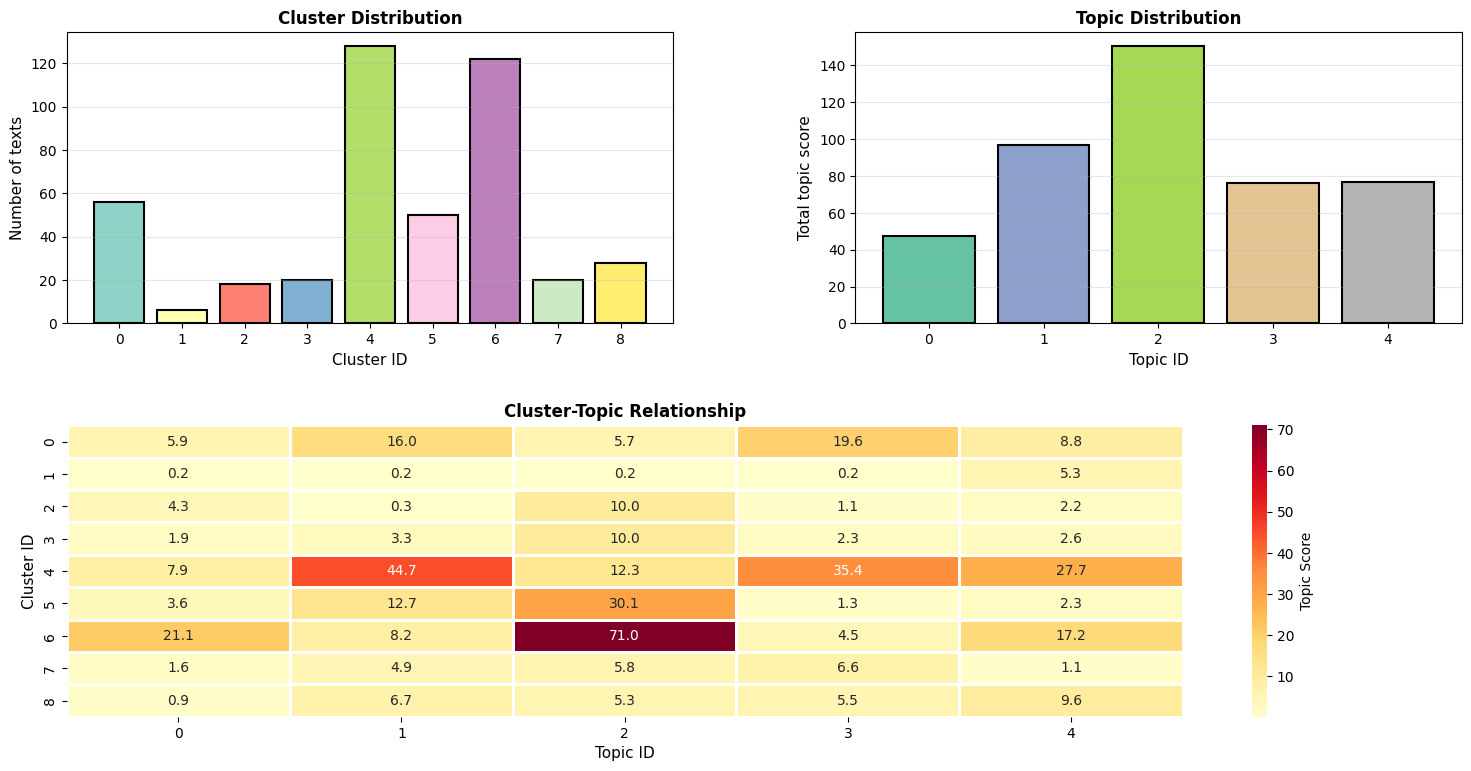

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

texts = df['Greek Transcription'].values  
file_names = df['File Name'].values

# TF-IDF
vectorizer = TfidfVectorizer(max_features=1000, min_df=5, max_df=0.8, stop_words=None) 
tfidf_matrix = vectorizer.fit_transform(texts)

# K-Means Clustering
n_clusters = 9 
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tfidf_matrix)

df['Cluster'] = cluster_labels

print(f"Clusters: {n_clusters}")
print(f"Cluster distribution:")
for i in range(n_clusters):
    count = (cluster_labels == i).sum()
    print(f"Cluster {i}: {count} texts ({count/len(texts)*100:.1f}%)")

# Analyze clusters
for cluster_id in range(n_clusters):
    cluster_texts = texts[cluster_labels == cluster_id]
    cluster_files = file_names[cluster_labels == cluster_id]
    
    print(f"\nCluster {cluster_id} ({len(cluster_texts)} texts)")
    
    avg_length = np.mean([len(t.split()) for t in cluster_texts])
    print(f"Average text length: {avg_length:.0f} words")
    
    # Top TF-IDF terms for this cluster
    cluster_center = kmeans.cluster_centers_[cluster_id]
    top_indices = cluster_center.argsort()[-10:][::-1]
    top_terms = vectorizer.get_feature_names_out()[top_indices]
    print(f"Top terms: {', '.join(top_terms)}")


count_vectorizer = CountVectorizer(max_features=500, min_df=5, max_df=0.8, stop_words=None)
count_matrix = count_vectorizer.fit_transform(texts)

# LDA
n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
lda_output = lda.fit_transform(count_matrix)

# Analyze common phrases in each cluster
for cluster_id in range(n_clusters):
    cluster_texts = texts[cluster_labels == cluster_id]
    
    # Generate bigrams for finding common phrases
    all_bigrams = []
    for text in cluster_texts:
        words = str(text).split()
        if len(words) >= 2:
            text_bigrams = [f"{words[i]} {words[i+1]}" for i in range(len(words)-1)]
            all_bigrams.extend(text_bigrams)
            
    bigram_freq = pd.Series(all_bigrams).value_counts()
    common_phrases = bigram_freq[bigram_freq > 1].head(5)
    
    print(f"  Cluster {cluster_id}:")
    if not common_phrases.empty:
        for phrase, count in common_phrases.items():
            print(f"'{phrase}': {count}")
    else:
        print("Δεν βρέθηκαν επαναλαμβανόμενες φράσεις")
        
# Top words per topic
feature_names = count_vectorizer.get_feature_names_out()

print(f"\nFound {n_topics} topics:\n")
for topic_id in range(n_topics):
    top_indices = lda.components_[topic_id].argsort()[-10:][::-1]
    top_words = feature_names[top_indices]
    
    print(f"Topic {topic_id}:")
    print(f"Words: {', '.join(top_words)}")
    
    # Find dominant cluster for this topic
    topic_scores = lda_output[:, topic_id]
    dominant_cluster = cluster_labels[topic_scores.argmax()]
    print(f" Most related cluster: {dominant_cluster}")



fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
colors = plt.cm.Set3(np.linspace(0, 1, n_clusters))

ax1.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(n_clusters))
ax1.set_xlabel('Cluster ID', fontsize=11)
ax1.set_ylabel('Number of texts', fontsize=11)
ax1.set_title('Cluster Distribution', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
topic_sums = lda_output.sum(axis=0)
ax2.set_xticks(range(n_topics))
ax2.bar(range(n_topics), topic_sums, color=plt.cm.Set2(np.linspace(0, 1, n_topics)), 
        edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Topic ID', fontsize=11)
ax2.set_ylabel('Total topic score', fontsize=11)
ax2.set_title('Topic Distribution', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

ax3 = fig.add_subplot(gs[1, :])
cluster_topic_matrix = np.zeros((n_clusters, n_topics))
for cluster_id in range(n_clusters):
    cluster_mask = cluster_labels == cluster_id
    cluster_topic_matrix[cluster_id] = lda_output[cluster_mask].sum(axis=0)

sns.heatmap(cluster_topic_matrix, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Topic Score'}, ax=ax3, linewidths=1)
ax3.set_xlabel('Topic ID', fontsize=11)
ax3.set_ylabel('Cluster ID', fontsize=11)
ax3.set_title('Cluster-Topic Relationship', fontsize=12, fontweight='bold')


plt.savefig('clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
#A6 katevassma aeneas 
import re
!git clone https://github.com/google-deepmind/predictingthepast.git
%pip install -r "C:\Users\dodor\OneDrive\Υπολογιστής\Εξόρυξη_ομαδική\data_mining_team\predictingthepast\requirements.txt"
def preprocess_inscription(text):

    #xrhsimopoioume regex gia na apomakrynoume ta mh ellhnika xarakthres kai na tous allaksoume me '?'
    clean_text = re.sub(r'[^Α-Ωα-ω \s]', '?', text)
    #kanoume strip ta kena
    return clean_text.strip()
df['cleaned_text'] = df['Greek Transcription'].apply(preprocess_inscription)
print(df['cleaned_text'].head(5))

fatal: destination path 'predictingthepast' already exists and is not an empty directory.


Note: you may need to restart the kernel to use updated packages.
0    ΣΤΟ ΚΑΙ ? ΔΙ ΚΟΣ Ε ? ΙΗ ΙΔΙ ΚΗ ΤΟΣ ΕΝΝΕΑ ? ΑΥΤ...
1    ΣΤΟ ΚΑΙ ? ΔΙ ΚΟΣ Ε ? ΙΗ ΙΔΙ ΚΗ ΤΟΣ ΕΝΝΕΑ ? ΑΥΤ...
2    Ρ ΧΟΝ ΤΟΣ ? ΡΙΣ ΤΟΝ Ι ΚΟΣ   ΑΡΙ ? Ν ? ? ? ΗΙ  ...
3    Ρ ΧΟΝ ΤΟΣ ? ΡΙΣ ΤΟΝ Ι ΚΟΣ   ΑΡΙ ? Ν ? ? ? ΗΙ  ...
4    ? ? ? ? ? ? ΕΑ ΜΜΑ ΝΤΕ ΥΜΑΣ ΙΔΩ ΚΕΝ ΕΥΧΗΣ ΕΞΑ ...
Name: cleaned_text, dtype: object


In [9]:
#%cd C:\Users\messi\Desktop\sxolh\4o Eτος\2ο Εξάμηνο\Εξόρυξη Δεδομένων\Ομαδική εργασία εξόρυξη δεδομένων\data_mining_team\predictingthepast
%cd C:\Users\dodor\OneDrive\Υπολογιστής\Εξόρυξη_ομαδική\data_mining_team\predictingthepast
%pip install .
!curl --output ithaca_153143996_2.pkl \
    https://storage.googleapis.com/ithaca-resources/models/ithaca_153143996_2.pkl
!curl --output iphi.json \
    https://storage.googleapis.com/ithaca-resources/models/iphi.json
!curl --output iphi_emb_xid153143996.pkl \
    https://storage.googleapis.com/ithaca-resources/models/iphi_emb_xid153143996.pkl

C:\Users\dodor\OneDrive\Υπολογιστής\Εξόρυξη_ομαδική\data_mining_team\predictingthepast


C:\Users\dodor\AppData\Roaming\Python\Python311\site-packages\IPython\core\magics\osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


Processing .\.
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for predictingthepast: filename=predictingthepast-0.1.0-py3-none-any.whl size=65006 sha256=6e3e7cd48d40d3a781fd7f3b2a29ebca82beebe125703beaa153026168888678
  Stored in directory: C:\Users\dodor\AppData\Local\Temp\pip-ephem-wheel-cache-hmmip_8l\wheels\d2\26\77\bb10ed8790bc11b3f4584ad9984f1caa7840d15929e4565dd2
Successfully built predictingthepast
  Attempting uninstall: predictingthepast
    Found existing installation: predictingthepast 0.1.0
    Uninstalling predictingthepast-0.1.0:
      Successfully uninstalled predictingthepast-0.1.0
Note: you may need to restart the kernel to use updated packages.


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  1 135.8M   1  2.68M   0      0  2.67M      0   00:50   00:01   00:49  2.68M
  5 135.8M   5  8.01M   0      0  3.99M      0   00:33   00:02   00:31  4.00M
 10 135.8M  10 14.77M   0      0  4.91M      0   00:27   00:03   00:24  4.92M
 16 135.8M  16 21.95M   0      0  5.47M      0   00:24   00:04   00:20  5.48M
 20 135.8M  20 28.45M   0      0  5.67M      0   00:23   00:05   00:18  5.67M
 25 135.8M  25 34.20M   0      0  5.68M      0   00:23   00:06   00:17  6.29M
 28 135.8M  28 38.60M   0      0  5.49M      0   00:24   00:07   00:17  6.09M
 32 135.8M  32 44.66M   0      0  5.56M      0   00:24   00:08   00:16  5.94M
 38 135.8M  38 51.84M   0      0  5.74M      0   00:23   00:09   00:14  5.95M
 42 135.8M  42 57.90M   0      0  5.77M      0   00:23   00:10 

In [ ]:
import jax
from predictingthepast.eval import inference
from predictingthepast.models.model import Model
from predictingthepast.util import alphabet as util_alphabet
import pickle
def load_checkpoint(path, language):
  with open(path, 'rb') as f:
    checkpoint = pickle.load(f)
  params = jax.device_put(checkpoint['params'])
  model = Model(**checkpoint['model_config'])
  forward = model.apply
  region_map = checkpoint['region_map']
  if language == 'latin':
    alphabet = util_alphabet.LatinAlphabet()
  elif language == 'greek':
    alphabet = util_alphabet.GreekAlphabet()
  else:
    raise ValueError(f'Unknown language: {language}')

  return checkpoint['model_config'], region_map, alphabet, params, forward
#fortwnoume to μοντέλο στη μνήμη
print("Φόρτωση του Aeneas model")
model_config, region_map, alphabet, params, forward = load_checkpoint(
    path="ithaca_153143996_2.pkl", 
    language="greek"
)
vocab_char_size = model_config['vocab_char_size']
nums=[5,15,35,25,62,150,200,250,420,368]
answers = []

    

for i in nums: 
    text = str(df['cleaned_text'].iloc[i])
    if len(text) > 750:
        text = text[:750]
        print(f"Γραμμή {i}: Το κείμενο κόπηκε στους 750 χαρακτήρες.")
    elif len(text) < 50:
        text = text.ljust(50, '?')
        print(f"Γραμμή {i}: Έγινε padding με '?' (Μικρό κείμενο).")
        
    
    attribution = inference.attribute(
        text,
        forward=forward,
        params=params,
        alphabet=alphabet,
        vocab_char_size=vocab_char_size,
    )
    attr_dict = json.loads(attribution.json())
    year_scores = attr_dict.get('year_scores', [])
    
    if year_scores:
        date_interval = 10
        date_min = -800
        
        #yplogismos apantisis
        best_idx = year_scores.index(max(year_scores))
        peak_year = (best_idx * date_interval) + date_min + (date_interval // 2)
        
    
    # emfanizoyme to apotelesma
    answers.append(peak_year)
    print(f"Γραμμή {i}: Εκτιμώμενη χρονική περίοδος: {peak_year} π.Χ.")




"""
Λόγω του ότι διαφορετικά μέρη υλοποιήθκαν σε διαφορετικές συσκευές, όταν πήγαμε νε τρέξουμε όλο το notebook από μια συσκευή για την τελική παράδοση,
έιχαν θέματα ορισμένες βιβλιοθήκες τα οποία δεν προλάβαμε να διορθώσουμε για να τρέχουν στην συγκεκριμένη συσκευή. Επομένως, το output αυτού και του 
επόμενου cell θα δωθούν στα σχόλια, αντεγραμμένα από το output συσκευής άλλου μέλους της ομάδας.


Φόρτωση του Aeneas model
Γραμμή 5: Εκτιμώμενη χρονική περίοδος: 215 π.Χ.
Γραμμή 15: Εκτιμώμενη χρονική περίοδος: 235 π.Χ.
Γραμμή 35: Έγινε padding με '?' (Μικρό κείμενο).
Γραμμή 35: Εκτιμώμενη χρονική περίοδος: 135 π.Χ.
Γραμμή 25: Εκτιμώμενη χρονική περίοδος: 205 π.Χ.
Γραμμή 62: Εκτιμώμενη χρονική περίοδος: 215 π.Χ.
Γραμμή 150: Έγινε padding με '?' (Μικρό κείμενο).
Γραμμή 150: Εκτιμώμενη χρονική περίοδος: -165 π.Χ.
Γραμμή 200: Εκτιμώμενη χρονική περίοδος: 65 π.Χ.
Γραμμή 250: Το κείμενο κόπηκε στους 750 χαρακτήρες.
Γραμμή 250: Εκτιμώμενη χρονική περίοδος: 135 π.Χ.
Γραμμή 420: Εκτιμώμενη χρονική περίοδος: -175 π.Χ.
Γραμμή 368: Το κείμενο κόπηκε στους 750 χαρακτήρες.
Γραμμή 368: Εκτιμώμενη χρονική περίοδος: -335 π.Χ.

"""

AttributeError: partially initialized module 'jax' has no attribute 'version' (most likely due to a circular import)

In [ ]:
#analysh me llm
#%%pip install -q -U google-generativeai
import google.generativeai as gemini
import time
api_key="" #insert key
gemini.configure(api_key=api_key)
model = gemini.GenerativeModel('gemini-2.5-flash')
for i in nums: 
    text = str(df['cleaned_text'].iloc[i])
    prompt = f"Δώσε μια εκτίμηση για την πιθανή χρονολογία του κειμένου χωρίς εκτενή επεξήγηση (π.χ. '-300πχ λόγω έντονου λεξιλογίου αυτής της περιόδου. τέλος.')η χρονολογία θέλω να είναι ακριβής και οχι πχ απο 150 μεχρ 350 πχ. Όπου υπάρχει το ερωτηματικό '?' σημαίνει ότι δεν γνωρίζουμε τι γράμμα είναι. Το κείμενο είναι στα αρχαία ελληνικά:\n\n{text}"
    try:
        answer = model.generate_content(prompt)
        print(f"Ανάλυση Gemini για το κείμενο {i}: {answer.text}")

    except Exception as e:
        print(f"Σφάλμα στο κείμενο {i}: {e}")
        answers[i] = f"Σφάλμα: {e}"

    time.sleep(10)



"""
Για τον ίδιο λόγο output σε σχόλια

Ανάλυση Gemini για το κείμενο 5: -50 πΧ, λόγω της χρήσης του ημισεληνιακού σίγμα (C) μαζί με το κανονικό Σ, χαρακτηριστικό της Ύστερης Ελληνιστικής/Πρώιμης Ρωμαϊκής περιόδου.
Ανάλυση Gemini για το κείμενο 15: ~150 μ.Χ. λόγω έντονης εμφάνισης ιωτακισμού (π.χ. ΧΑΙΡΑΙΤΕ αντί ΧΑΙΡΕΤΕ, ΕΠΑΡΟΔΕΙΤΕ αντί ΕΠΑΡΟΔΕΥΕΤΕ, ΧΑΡΕΙΝ αντί ΧΑΡΙΝ) που χαρακτηρίζει την Ελληνιστική και κυρίως τη Ρωμαϊκή περίοδο.
Ανάλυση Gemini για το κείμενο 35: 2ος αιώνας μ.Χ.
Ανάλυση Gemini για το κείμενο 25: -250 μΧ λόγω του μοτίβου "ζώντα ήρω" (ενδείκνυται για ρωμαϊκές επιγραφές) και της μεταγενέστερης Κοινής Ελληνικής ορθογραφίας/γραμματικής (ΣΕΡΑΠΟΥΝ, ΕΣ).
Ανάλυση Gemini για το κείμενο 62: -385 π.Χ. λόγω της χρήσης του πλήρους Ιωνικού αλφαβήτου (με Η και Ω), που υιοθετήθηκε στην Αθήνα το 403/402 π.Χ., και των τυπικών αθηναϊκών πολιτικών όρων ('Βουλή', 'Πρύτανις', 'Ψηφισθαι') που χαρακτήρισαν τα δημόσια ψηφίσματα της κλασικής περιόδου.
Ανάλυση Gemini για το κείμενο 150: 390 π.Χ. - Λόγω της χρήσης του Ιωνικού αλφαβήτου (Ω, Η).
Ανάλυση Gemini για το κείμενο 200: 223 π.Χ.

Λόγω: Η αναφορά στον επώνυμο άρχοντα Νικήτη (πιθανώς 'ΝΙΚΗΤΟΥ' ή παραλλαγή του 'ΝΙΚΗΤΕΥΟΝΤΟΣ') και το αθηναϊκό δημωτικό Υφιδίων (ΥΦΙΔΙΟΣ) τοποθετούν το κείμενο στην ελληνιστική περίοδο, με τον Νικήτη να είναι άρχων το 223/222 π.Χ. Η αναφορά σε «γυμνάσιο» ταιριάζει επίσης πλήρως στην περίοδο αυτή.
Ανάλυση Gemini για το κείμενο 250: 135 μ.Χ. λόγω της αναφοράς στον θεοποιημένο Αντίνοο και της παρουσίας ρωμαϊκών ονομάτων (όπως ο Μέσσιος και ο Ούλπιος).
Ανάλυση Gemini για το κείμενο 420: 294/3 π.Χ. λόγω της παρουσίας του Στρατοκλή του Ευθυδήμου ως εισηγητή και του άρχοντα Επιτελή.
Ανάλυση Gemini για το κείμενο 368: 316/315 π.Χ. λόγω της αναφοράς στον άρχοντα Ιφιλοκλέα.
"""

448


In [ ]:
#MEROS B
#%pip install opencv-python
import os
import cv2 

#load images from dataset

img_ids = set()
loaded_images = {}  # dictionary tο map image titles to their corresponding image

images_dirs = ["", ""] #image paths

for d in images_dirs:
    if os.path.exists(d):
        for f in os.listdir(d):
            if f.endswith('.png'):
                img_id = f.replace('.png', '')
                img_ids.add(img_id)
                
                full_path = os.path.join(d, f) #create path
                
                img = cv2.imread(full_path) #load image with cv2 library
                
                if img is not None:
                    loaded_images[img_id] = img   #create a dictionary entry

print(f"{len(loaded_images)} were loaded")


190 were loaded


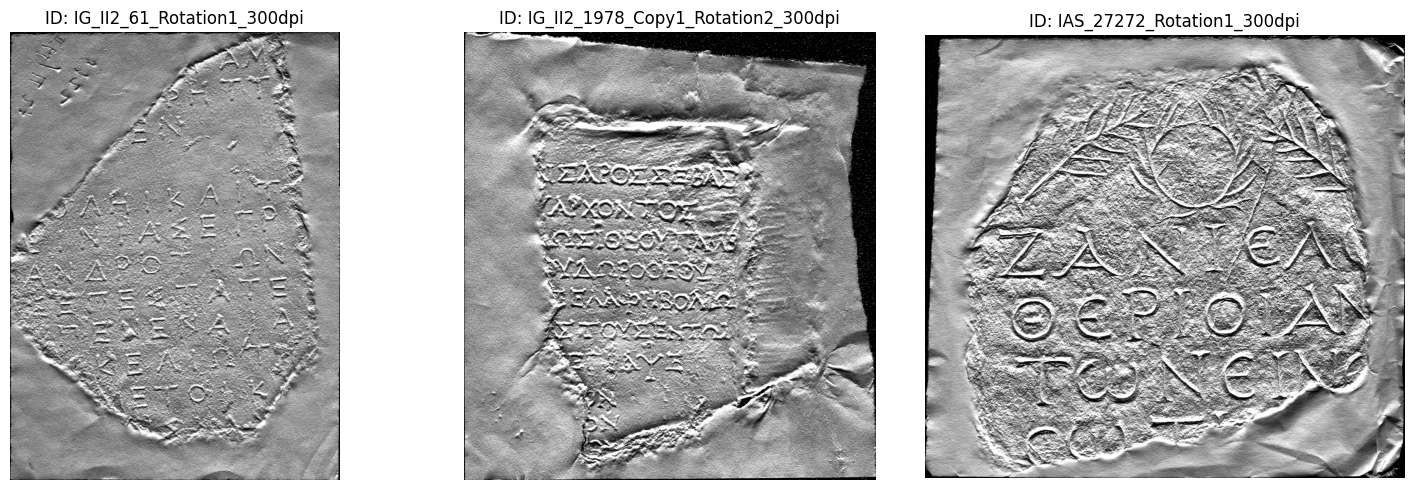

In [5]:
import matplotlib.pyplot as plt
import random

all_ids = list(loaded_images.keys())  # convert image ids to a list

num_samples = min(3, len(all_ids))  # select up to 3 samples
sample_ids = random.sample(all_ids, num_samples)

fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

if num_samples == 1:
    axes = [axes]

for ax, img_id in zip(axes, sample_ids):
    img = loaded_images[img_id]
    if img is None:
        continue

    if img.ndim == 3 and img.shape[2] == 3:
        img_rgb = img[..., ::-1]
    else:
        img_rgb = img

    ax.imshow(img_rgb)
    ax.set_title(f"ID: {img_id}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

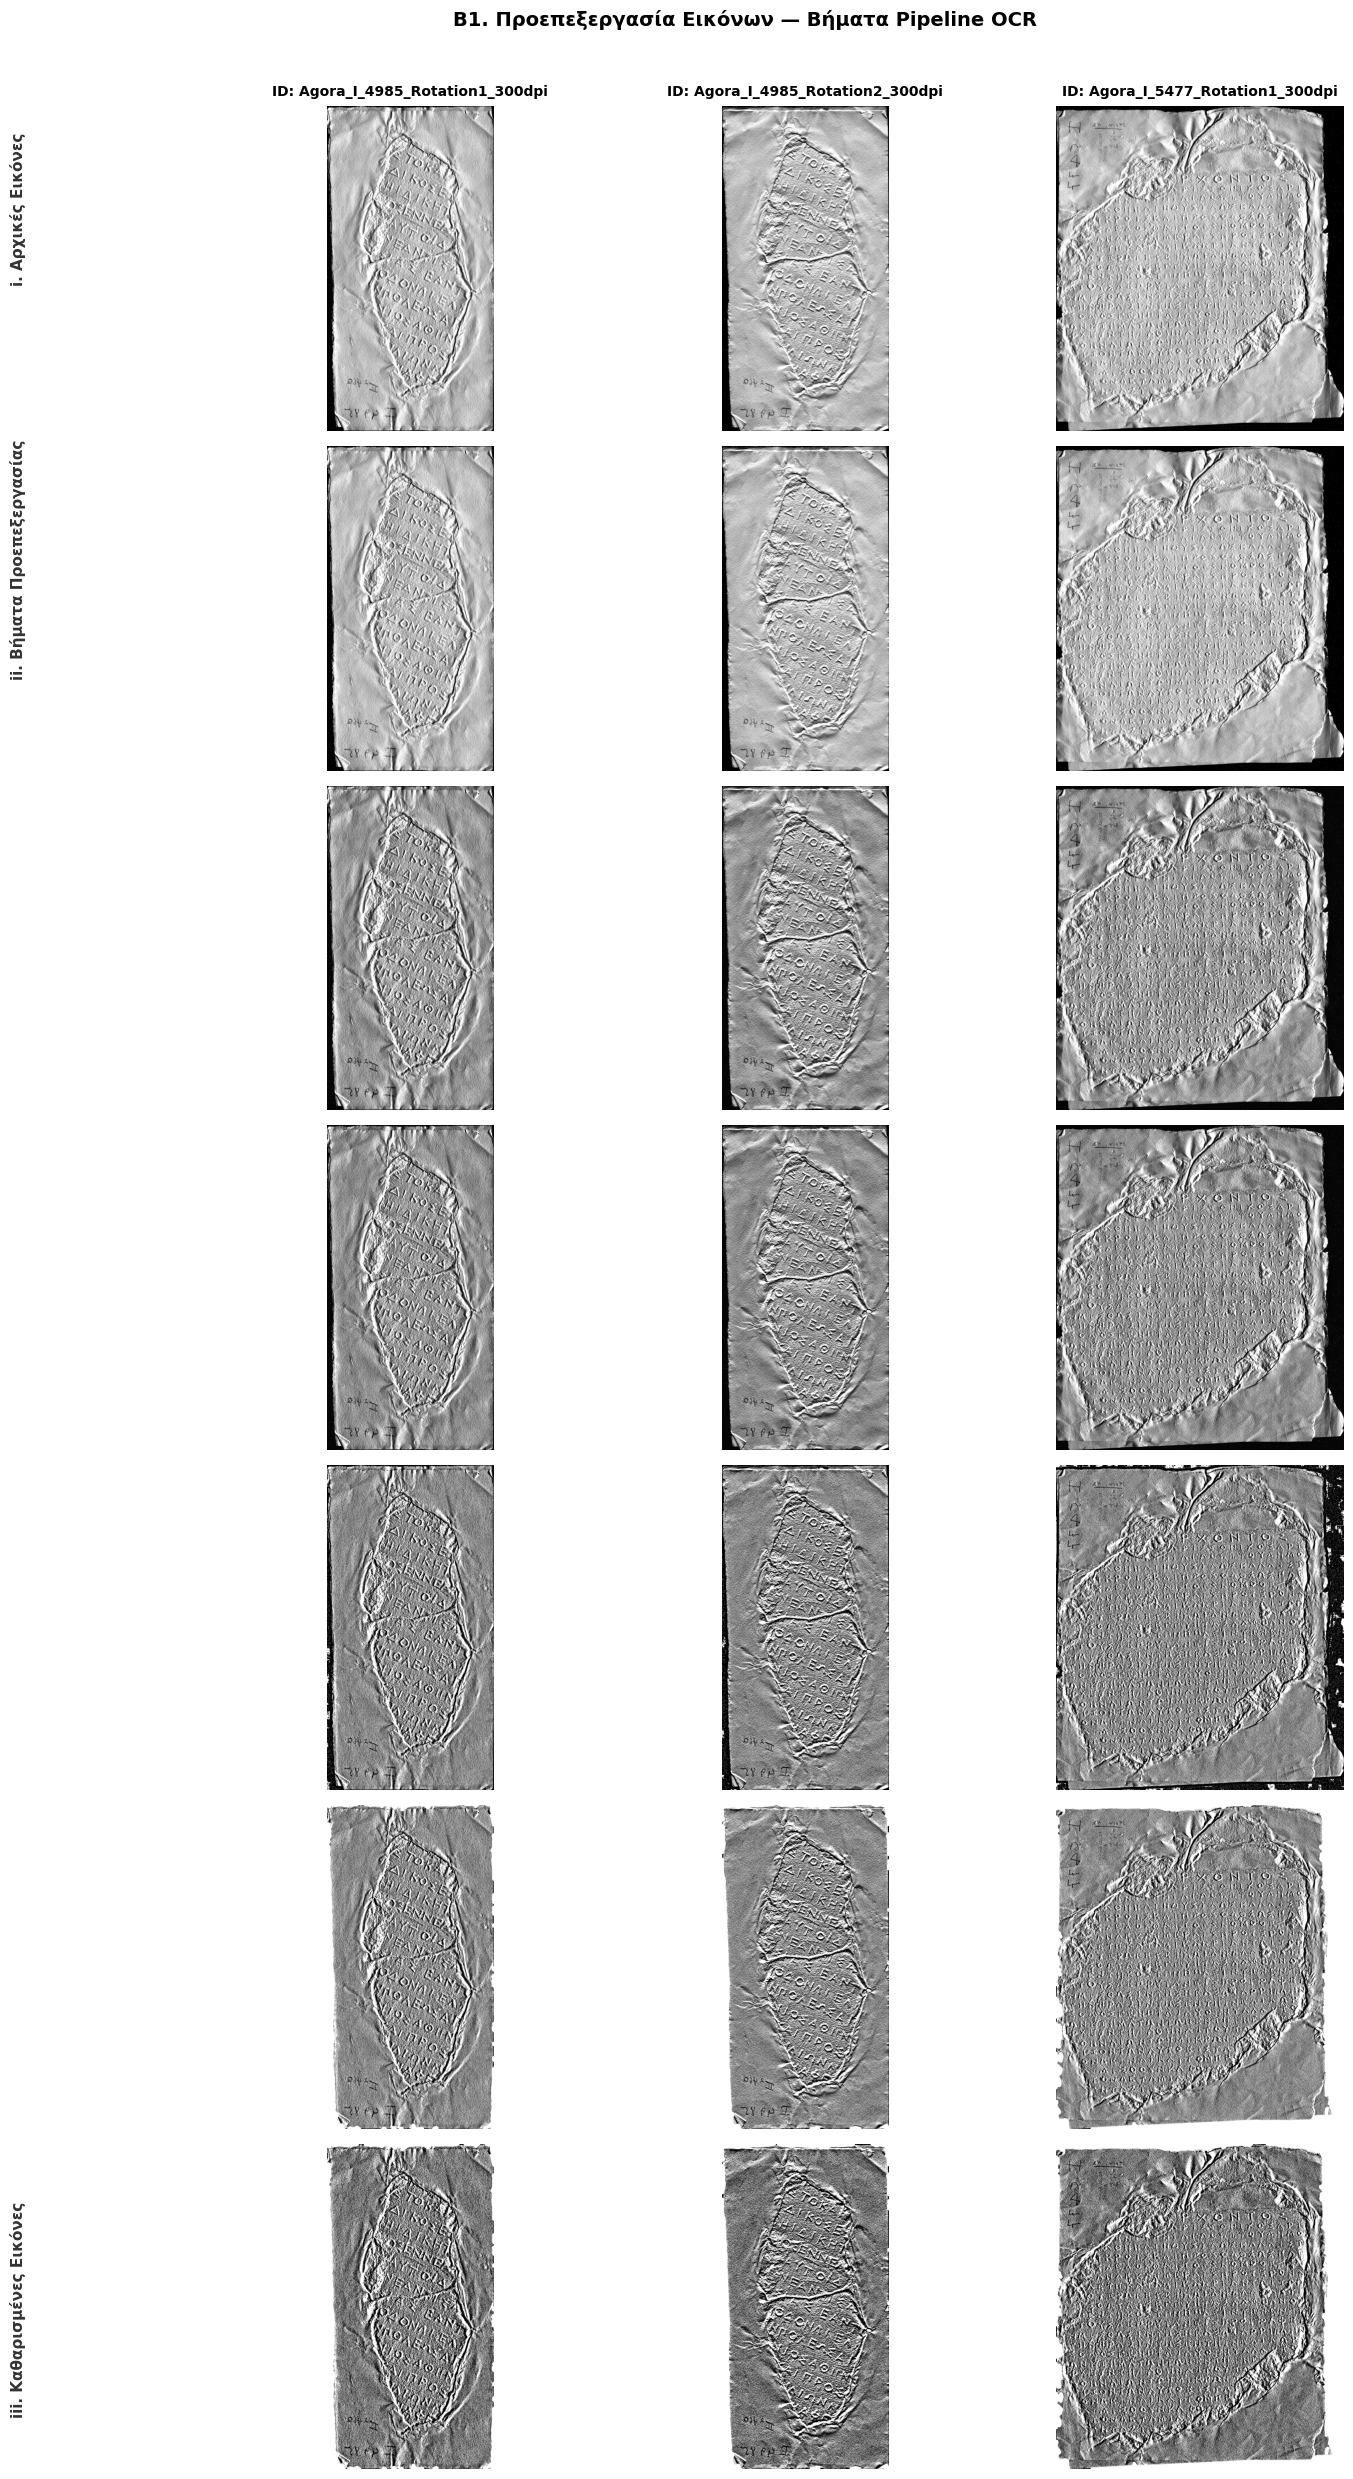

Αποθηκεύτηκε: B1_preprocessing_pipeline.png
Ready for OCR: 190 images

Έτοιμες για OCR: 190 εικόνες


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def img_to_grayscale(img):
    if len(img.shape) == 3:  #if image has 3 colour chanels return greyscale brightness
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img.copy()   #if image was already greyscale return a copy

def img_clahe(gray):
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(16, 16)) #clip image into tiles to enhance contrast inside
    return clahe.apply(gray)

def img_unsharp_mask(enhanced):
    blurred = cv2.GaussianBlur(enhanced, (0, 0), sigmaX=3) #create a blurred version of the image 
    return cv2.addWeighted(enhanced, 1.8, blurred, -0.8, 0)  #remove blur with weights to enhance sharpness of edges and letters

def img_sauvola_threshold(img, window_size=61, k=0.12, R=128):
    img_f = img.astype(np.float32)   #turn image into 32bit
    mean = cv2.boxFilter(img_f, -1, (window_size, window_size))  #calculate average brightness of 61x61 boxes in the image
    mean_sq = cv2.boxFilter(img_f**2, -1, (window_size, window_size))  
    std = np.sqrt(np.maximum(0, mean_sq - mean**2))   #calculate standard deviation in contrast
    threshold = mean * (1.0 + k * (std / R - 1.0))  #implement sauvolas formula 
    binary = np.zeros_like(img)  #create binary image 
    binary[img_f > threshold] = 255
    if np.mean(binary) < 127:   #if image is in the black side of the colour invert it 
        binary = cv2.bitwise_not(binary)
    return binary

def img_find_slab_and_mask(gray, binary):
    rough = cv2.GaussianBlur(gray, (51, 51), 0)  #apply gaussian blur to find shape of the slab
    _, slab_mask = cv2.threshold(rough, 0, 255,    #separate the image to black and white
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    if np.sum(slab_mask > 0) < (slab_mask.size * 0.2):  #if white pixels are less than 20% of surface invert to fix
        slab_mask = cv2.bitwise_not(slab_mask)
    
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))  #use a kernel to pass the image and make the slab more unisom
    slab_mask = cv2.morphologyEx(slab_mask, cv2.MORPH_CLOSE, kernel_large)
    
    contours, _ = cv2.findContours(slab_mask, cv2.RETR_EXTERNAL,   #find outlines of white shapes 
                                    cv2.CHAIN_APPROX_SIMPLE)
    slab_mask_clean = np.zeros_like(slab_mask)
    if contours:    
        largest = max(contours, key=cv2.contourArea)
        cv2.drawContours(slab_mask_clean, [largest], -1, 255,  #create a new image and draw the outlines
                         thickness=cv2.FILLED)
    
    kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))  #erode the white edges
    slab_mask_clean = cv2.erode(slab_mask_clean, kernel_erode)
    
    result = binary.copy()
    result[slab_mask_clean == 0] = 255

    return result, slab_mask_clean

def img_denoise(binary):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))  
    return cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)  #use the 2x2 kernel to eliminate noise 



def full_pipeline(img):
    steps = {}
    steps['0_original'] = img.copy()
    gray   = img_to_grayscale(img)       
    steps['1_grayscale']  = gray
    clahe  = img_clahe(gray)               
    steps['2_clahe'] = clahe
    sharp  = img_unsharp_mask(clahe)
    steps['3_sharpened']  = sharp
    binary = img_sauvola_threshold(sharp)
    steps['4_sauvola']    = binary
    masked, slab = img_find_slab_and_mask(gray, binary)
    steps['5_masked'] = masked
    final  = img_denoise(masked)
    steps['6_final'] = final
    
    return steps


STEP_LABELS = {
    '0_original':  'Αρχική Εικόνα',
    '1_grayscale': 'Βήμα 1: Grayscale',
    '2_clahe':     'Βήμα 2: CLAHE\n(Βελτίωση Αντίθεσης)',
    '3_sharpened': 'Βήμα 3: Unsharp Mask\n(Ακόνισμα)',
    '4_sauvola':   'Βήμα 4: Sauvola\n(Binarization)',
    '5_masked':    'Βήμα 5: Slab Mask\n(Αφαίρεση Φόντου)',
    '6_final':     'Βήμα 6: Morph. Opening\n(Τελική Εικόνα)',
}

def visualize_pipeline(loaded_images, sample_ids=None):
    if sample_ids is None:
        sample_ids = list(loaded_images.keys())[:3]
    
    n_imgs  = len(sample_ids)
    n_steps = len(STEP_LABELS)   
    
    fig, axes = plt.subplots(
        n_steps, n_imgs,
        figsize=(5 * n_imgs, 3.5 * n_steps),
        facecolor='white'
    )
    
    all_steps = {sid: full_pipeline(loaded_images[sid]) for sid in sample_ids}  #calculate the preprocesing pipeline for the images
    
    for col, sid in enumerate(sample_ids):
        steps = all_steps[sid]
        for row, (key, label) in enumerate(STEP_LABELS.items()):
            ax = axes[row][col]
            img_to_show = steps[key]
            
            if len(img_to_show.shape) == 2:
                ax.imshow(img_to_show, cmap='gray', vmin=0, vmax=255)
            else:
                ax.imshow(cv2.cvtColor(img_to_show, cv2.COLOR_BGR2RGB))
            
            # Column header (image ID) on top row only
            if row == 0:
                ax.set_title(f'ID: {sid}', fontsize=10, 
                             fontweight='bold', pad=8)
            
            # Row label on leftmost column only
            if col == 0:
                ax.set_ylabel(label, fontsize=9, 
                              rotation=0, labelpad=120,
                              va='center', ha='right')
            
            ax.axis('off')
    
    section_rows = {0: 'i. Αρχικές Εικόνες', 
                    1: 'ii. Βήματα Προεπεξεργασίας',
                    6: 'iii. Καθαρισμένες Εικόνες'}
    
    for row_idx, section_title in section_rows.items():
        fig.text(
            0.01, 
            1 - (row_idx / n_steps) - (0.5 / n_steps),
            section_title,
            fontsize=11, fontweight='bold', color='#333333',
            va='center', rotation=90
        )
    
    plt.suptitle(
        'Β1. Προεπεξεργασία Εικόνων — Βήματα Pipeline OCR',
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout(rect=[0.08, 0, 1, 1])
    plt.savefig('B1_preprocessing_pipeline.png', 
                dpi=150, bbox_inches='tight', 
                facecolor='white')
    plt.show()
    print("Αποθηκεύτηκε: B1_preprocessing_pipeline.png")
    return all_steps

sample_ids = list(loaded_images.keys())[:3]
all_preprocessed = visualize_pipeline(loaded_images, sample_ids)

#preprocessed_images = {sid: steps['6_final'] 
                  #      for sid, steps in all_preprocessed.items()}
preprocessed_images = {
    img_id: full_pipeline(img)['6_final']
    for img_id, img in loaded_images.items()
}
print(f"Ready for OCR: {len(preprocessed_images)} images")
print(f"\nΈτοιμες για OCR: {len(preprocessed_images)} εικόνες")

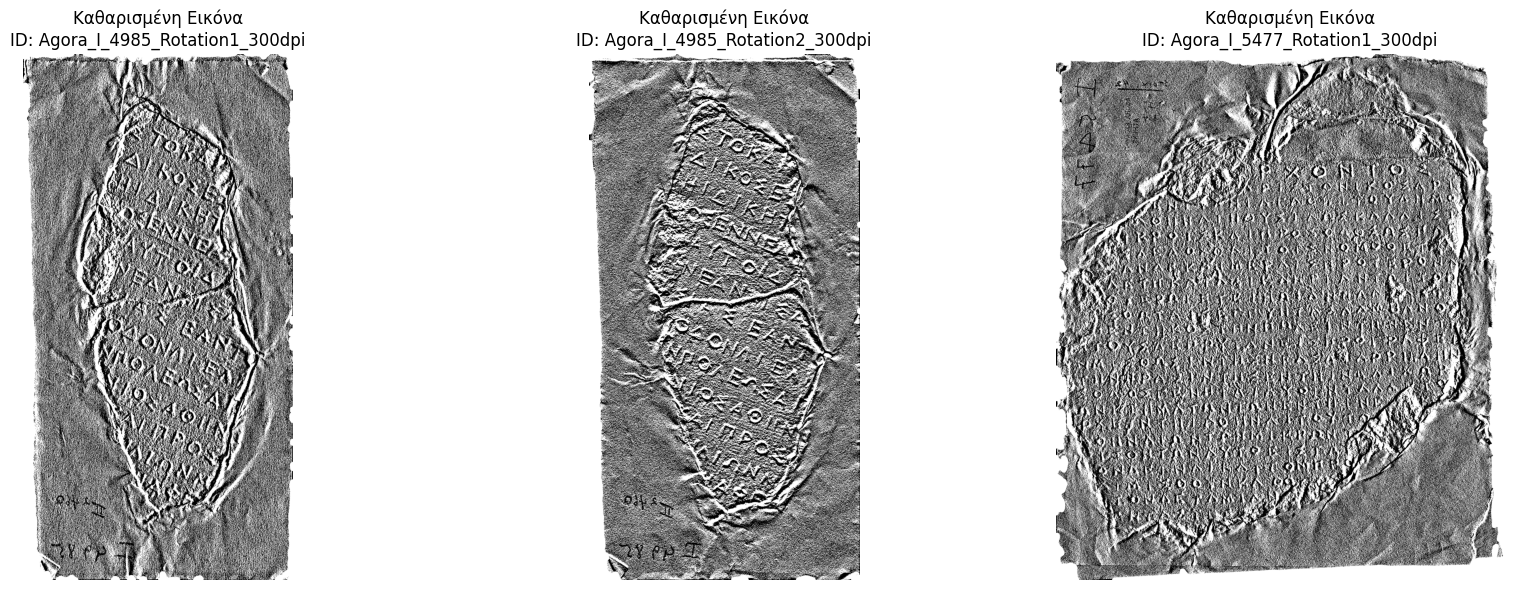

In [25]:
# plot the cleaned versions of the first 3 images we displayed for comparison
fig, axes = plt.subplots(1, num_samples, figsize=(18, 6))

if num_samples == 1:
    axes = [axes]

for ax, img_id in zip(axes, sample_ids):
    cleaned_img = preprocessed_images[img_id] #take the cleaned version
    
    ax.imshow(cleaned_img, cmap='gray')
    ax.set_title(f"Καθαρισμένη Εικόνα\nID: {img_id}", fontsize=12)
    ax.axis('off')  # Κρύβουμε τους άξονες X και Y

plt.tight_layout()
plt.show()

In [26]:
#B2

import torch
from transformers import ViTImageProcessor, ViTModel
from PIL import Image
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  #set device for transformers

#load ViT models
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTModel.from_pretrained('google/vit-base-patch16-224').to(device)
model.eval() 

image_embeddings = {}

with torch.no_grad():
    for img_id, img in loaded_images.items():
        #turn images into RGB
        if len(img.shape) == 3:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            
        pil_img = Image.fromarray(img_rgb)
        
        inputs = processor(images=pil_img, return_tensors="pt").to(device) #prepare image
        
        outputs = model(**inputs)
        
        embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()
        
        image_embeddings[img_id] = embedding


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


c:\Users\dodor\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


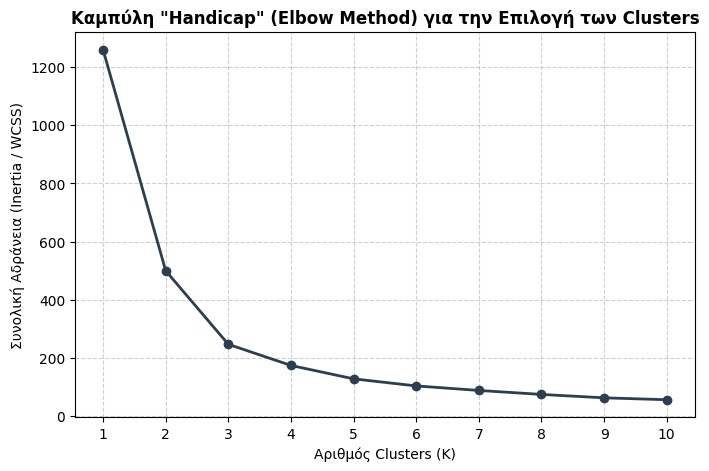

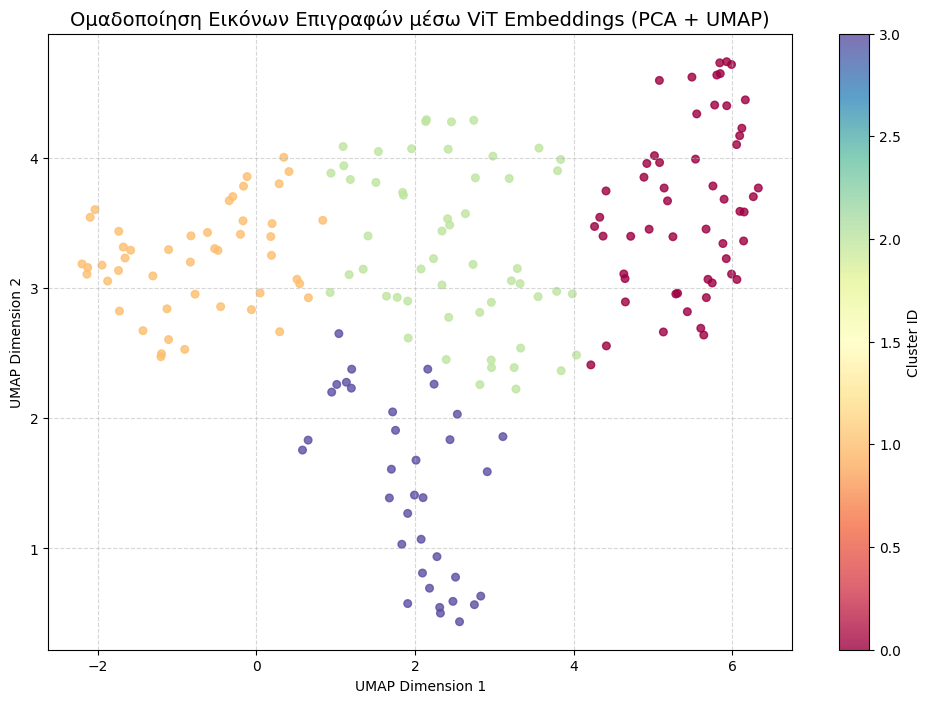

In [27]:
%pip install umap-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap


# turn embeddings into a matrix
img_ids = list(image_embeddings.keys())
embeddings_matrix = np.array([image_embeddings[uid] for uid in img_ids])

pca = PCA(n_components=50, random_state=42)  #apply PCA, reduce to 50 features
pca_features = pca.fit_transform(embeddings_matrix)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)  #make umap look for closest 15 neighbors
umap_embeddings = reducer.fit_transform(pca_features)

# Υπολογισμός Inertia για τιμές K από 1 έως 10
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(umap_embeddings)
    inertia_values.append(km.inertia_)

# Σχεδίαση της καμπύλης Elbow
plt.figure(figsize=(8, 5), facecolor='white')
plt.plot(K_range, inertia_values, marker='o', linestyle='-', color='#2c3e50', linewidth=2)
plt.title('Καμπύλη "Handicap" (Elbow Method) για την Επιλογή των Clusters', fontsize=12, fontweight='bold')
plt.xlabel('Αριθμός Clusters (K)')
plt.ylabel('Συνολική Αδράνεια (Inertia / WCSS)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)

num_clusters = 4   # group into 4 clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)  #apply kmenans algorithm for clustering
cluster_labels = kmeans.fit_predict(umap_embeddings)

# plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], 
                      c=cluster_labels, cmap='Spectral', s=30, alpha=0.8)

plt.colorbar(scatter, label='Cluster ID')
plt.title('Ομαδοποίηση Εικόνων Επιγραφών μέσω ViT Embeddings (PCA + UMAP)', fontsize=14)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()





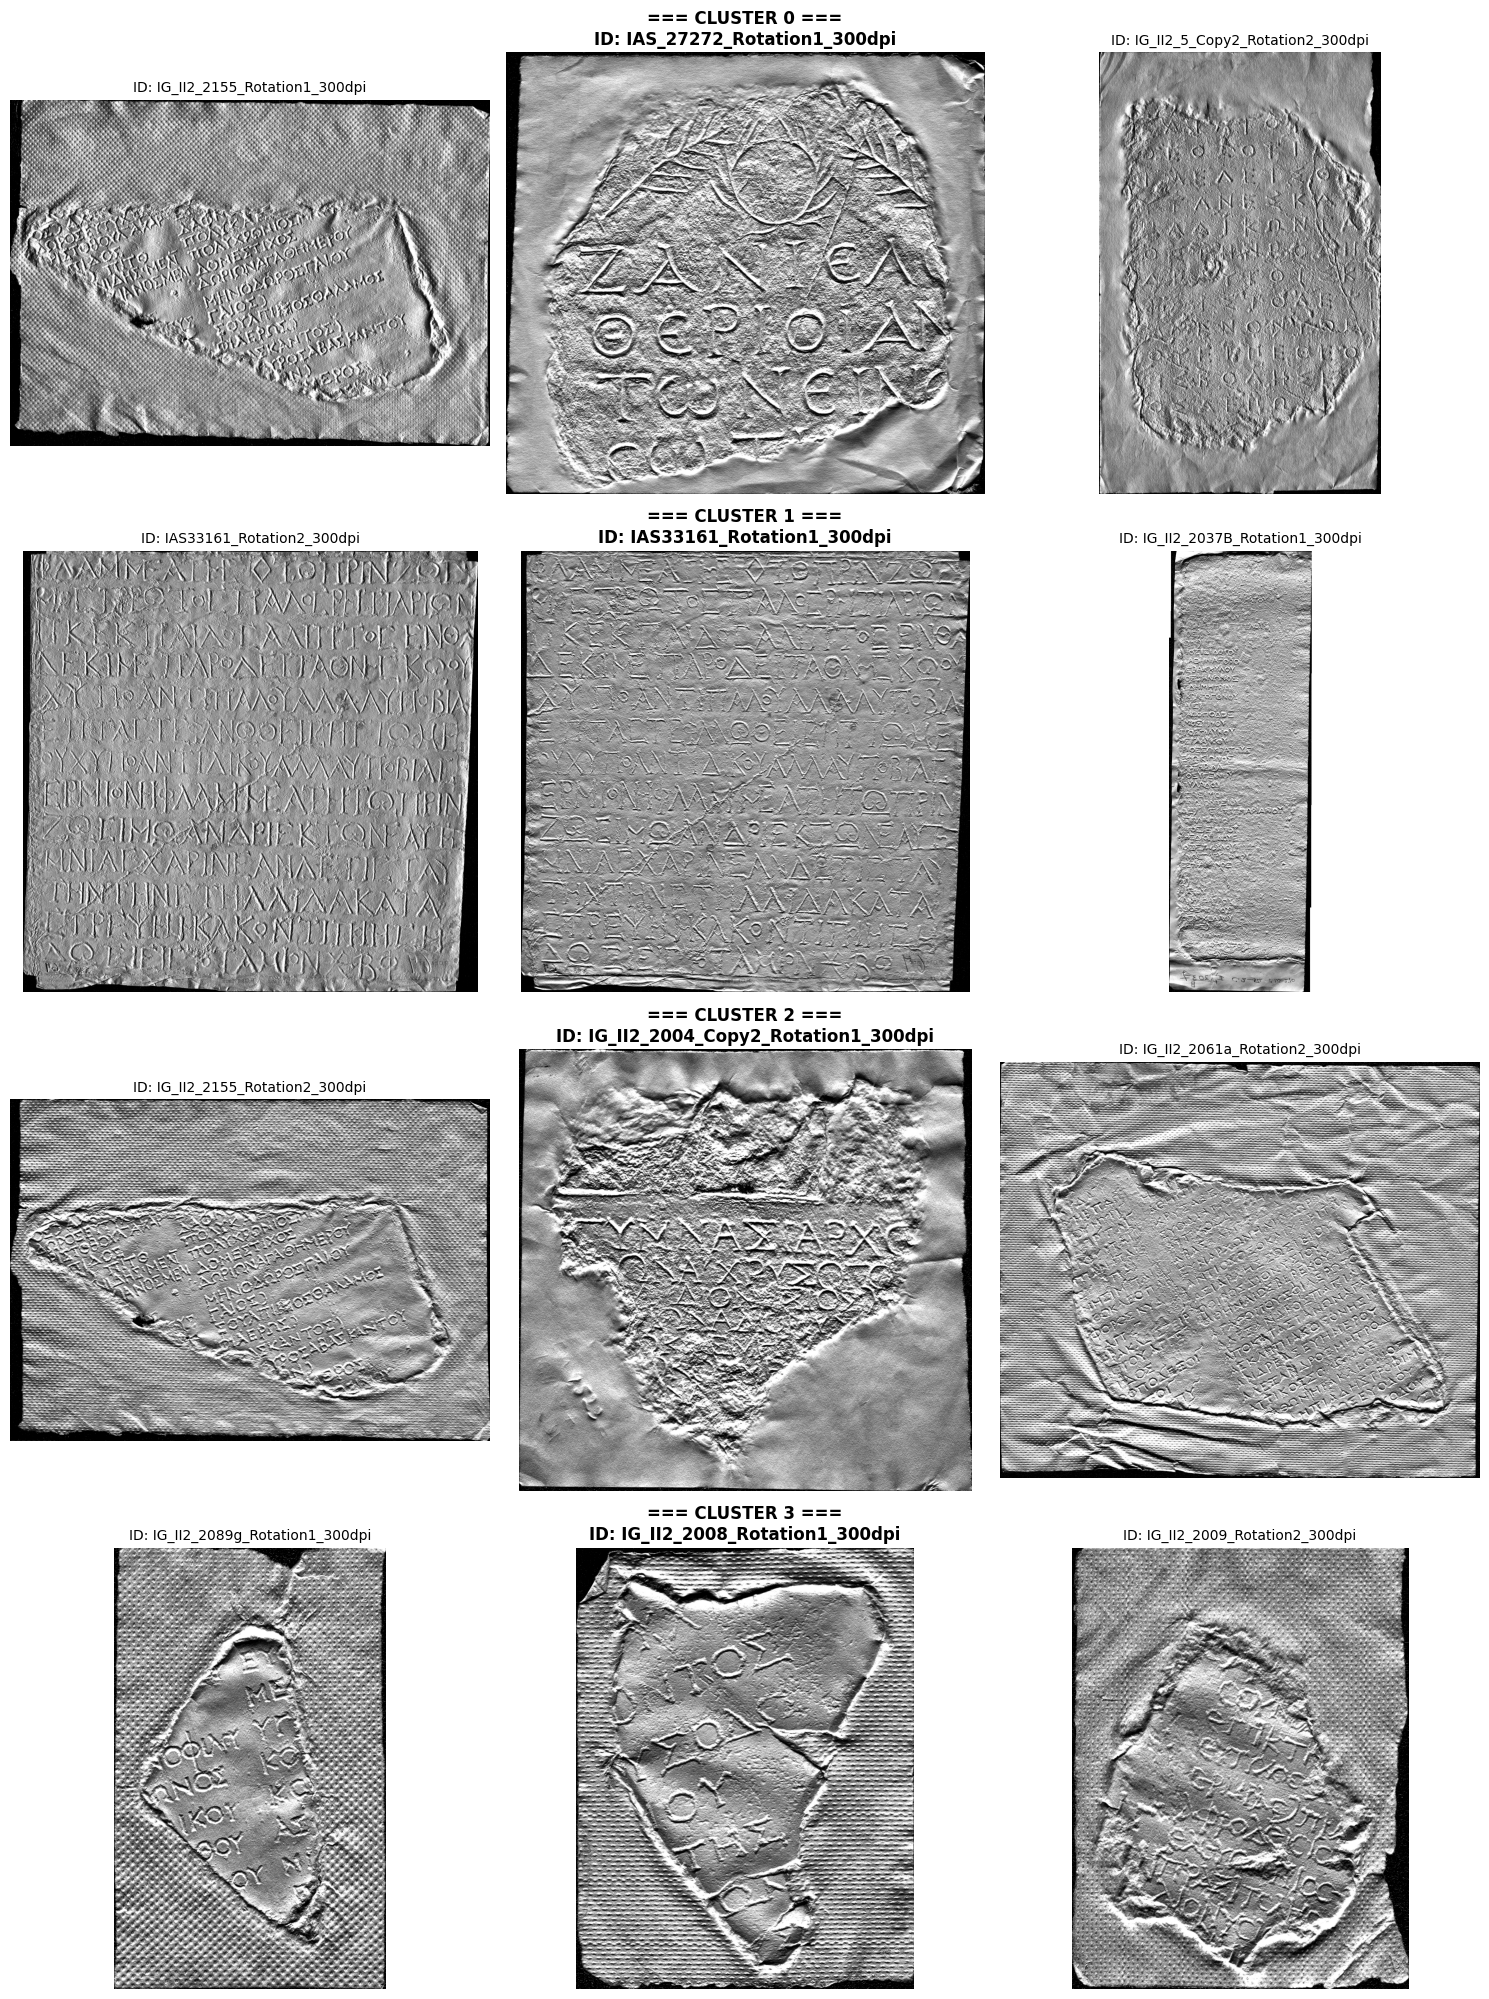

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# take the centroids of the clustering we did prior
centroids = kmeans.cluster_centers_

# plot with 4 rows to represent each cluster 
fig, axes = plt.subplots(num_clusters, 3, figsize=(15, 5 * num_clusters))


for cluster_id in range(num_clusters):
    # find indexes of images in a cluster
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    
    # take umap embeddings of images in the cluster 
    cluster_coords = umap_embeddings[cluster_indices]
    
    # euclidean distance from the center of the cluster 
    centroid = centroids[cluster_id]
    distances = np.linalg.norm(cluster_coords - centroid, axis=1)
    
    # take 3 closest indexes
    closest_local_indices = np.argsort(distances)[:3]
    closest_global_indices = cluster_indices[closest_local_indices]
    
    # show the 3 images of the cluster
    for col_idx, img_idx in enumerate(closest_global_indices):
        img_id = img_ids[img_idx]
        
        #load the original image 
        original_img = loaded_images[img_id]
        
        # turn into RGB
        if len(original_img.shape) == 3:
            img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        else:
            img_rgb = cv2.cvtColor(original_img, cv2.COLOR_GRAY2RGB)
            
        ax = axes[cluster_id, col_idx]
        ax.imshow(img_rgb)
        
        # show by cluster id
        if col_idx == 1:
            ax.set_title(f"=== CLUSTER {cluster_id} ===\nID: {img_id}", fontsize=12, fontweight='bold')
        else:
            ax.set_title(f"ID: {img_id}", fontsize=10)
            
        ax.axis('off')

plt.tight_layout()
plt.show()

Βλέποντας τα clusters παρατηρούμε ότι πράγματι μέσα σε κάθε cluster βρίσονται ζεύγη εικόνων/παρόμοιες εικόνες. Σε κάθε cluster βλέπουμε ότι όλες οι εικόνες εντός του έχουν παρόμοια γεωμετρία ως προς το σχήμα της πλάκας καθώς και παρόμοια ευκρίνεια και δομή των γραμμάτων. Επίσης παρατηρούμε και πραγματικά ζεύγη της ίδιας εικόνας καθώς έχουμε εικόνες με το ίδιο ID, αλλά διαφορετικό rotation. Οι εικόνες κάθε cluster φαίνεται ότι είναι παρόμοιας εποχής καθώς τα προθέματα στην ονοματοδοσία των αρχείων μέσα στα clusters είναι παρόμοια. 

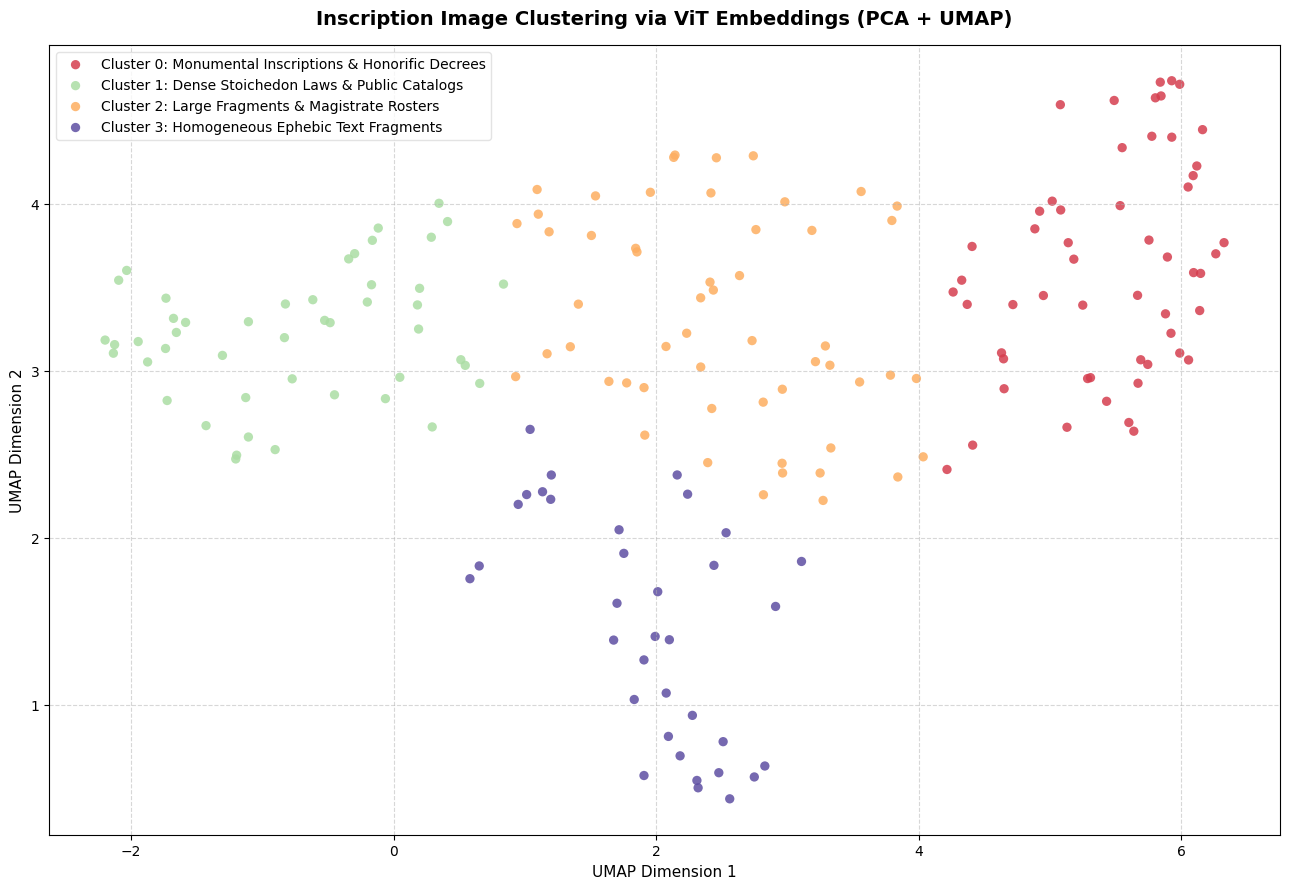

In [29]:
#cluster titles we created maually
cluster_titles = {
    0: "Cluster 0: Monumental Inscriptions & Honorific Decrees",
    1: "Cluster 1: Dense Stoichedon Laws & Public Catalogs",
    2: "Cluster 2: Large Fragments & Magistrate Rosters",
    3: "Cluster 3: Homogeneous Ephebic Text Fragments"
}

plt.figure(figsize=(13, 9))

#apply the colors we had before
colors = ['#d53e4f', '#abdda4', '#fdae61', '#5e4fa2']

for cluster_id in range(num_clusters):
    #find points in certain cluster 
    idx = np.where(cluster_labels == cluster_id)
    
    plt.scatter(
        umap_embeddings[idx, 0], 
        umap_embeddings[idx, 1], 
        c=colors[cluster_id], 
        label=cluster_titles[cluster_id], # Εδώ μπαίνει ο αγγλικός τίτλος
        s=45, 
        alpha=0.85,
        edgecolors='none'
    )

plt.title('Inscription Image Clustering via ViT Embeddings (PCA + UMAP)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('UMAP Dimension 1', fontsize=11)
plt.ylabel('UMAP Dimension 2', fontsize=11)

plt.legend(loc='best', fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:

%pip install google-genai
import numpy as np
from google import genai
from google.genai import types

# initialize gemini with api key
client = genai.Client(api_key="YOUR_GEMINI_API_KEY")

# gather clusters and positions
cluster_representative_names = {}
centroids = kmeans.cluster_centers_
for cluster_id in range(num_clusters):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    cluster_coords = umap_embeddings[cluster_indices]
    distances = np.linalg.norm(cluster_coords - centroids[cluster_id], axis=1)
    closest_indices = np.argsort(distances)[:5]
    filenames = [img_ids[idx] for idx in cluster_indices[closest_indices]]
    cluster_representative_names[cluster_id] = filenames

automated_cluster_titles = {}

for cluster_id, filenames in cluster_representative_names.items():
    prompt = f"""
    You are an expert epigraphist and data scientist. 
    A clustering algorithm has grouped the following ancient Greek inscription images together based on visual similarity.
    The filenames represent their catalog numbers in the Inscriptiones Graecae (IG):
    {", ".join(filenames)}
    
    Based on these filenames, identify the common historical period, inscription type, or archaeological context.
    Provide a single, concise academic title in English for this cluster (maximum 8 words).
    Return ONLY the title, nothing else. Do not include markdown formatting or introduction.
    """
    
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt,
        config=types.GenerateContentConfig(temperature=0.2) 
    )
    
    llm_title = response.text.strip()
    automated_cluster_titles[cluster_id] = f"Cluster {cluster_id}: {llm_title}"
    print(f"-> Cluster {cluster_id} Named by Gemini: {llm_title}")


-> Cluster 0 Named by Gemini: Monumental Stone Inscriptions from Attica
-> Cluster 1 Named by Gemini: Roman Imperial Ephebic Inscriptions from Athens
-> Cluster 2 Named by Gemini: Roman Imperial Ephebic Lists from Athens
-> Cluster 3 Named by Gemini: Athenian Ephebic Lists of the Roman Imperial Period


In [ ]:
import cv2
import time
import json
import os
from google import genai
import PIL.Image

client = genai.Client(api_key="") #insert key

# 1. Φόρτωση προηγούμενων αποτελεσμάτων (αν υπάρχουν) για να μην χάνετε πρόοδο
backup_file = "ocr_results_backup.json"
if os.path.exists(backup_file):
    with open(backup_file, "r", encoding="utf-8") as f:
        ocr_results = json.load(f)
    print(f"Loaded {len(ocr_results)} existing results from backup.")
else:
    ocr_results = {}
    print("No previous backup found. Starting fresh.")

items = list(preprocessed_images.items())
total = len(items)

print(f"Starting OCR pipeline for {total} images...\n")

prompt = """
You are an expert epigraphist participating in the ICDAR Competition for Text Recognition on Greek Squeezes.
Analyze the provided preprocessed image of an ancient Greek inscription.
Perform Transcription (OCR) of the ancient Greek text visible on the stone.

Rules:
1. Provide the transcription ONLY in capital Ancient Greek characters.
2. Do not include spaces between words if they are written in continuous script (scriptura continua), OR restore them if you can identify the words confidently.
3. Use asterisks * for damaged or missing text that you can infer from the context.
4. Return ONLY the transcribed Greek text. Do not write any English introduction, markdown blocks, or explanations.
"""

for i, (img_id, cleaned_matrix) in enumerate(items, 1):
    # ΑΝ η εικόνα έχει ήδη επεξεργαστεί επιτυχώς στο παρελθόν, την προσπερνάμε
    if img_id in ocr_results and ocr_results[img_id] != "[ERROR]":
        print(f"[{i}/{total}] Skipping: {img_id} (Already processed)")
        continue

    print(f"[{i}/{total}] Processing: {img_id}...")

    rgb_img = cv2.cvtColor(cleaned_matrix, cv2.COLOR_GRAY2RGB)
    pil_img = PIL.Image.fromarray(rgb_img)

    for attempt in range(3):
        try:
            response = client.models.generate_content(
                model='gemini-2.5-flash',
                contents=[pil_img, prompt]
            )
            # Αποθήκευση στη μνήμη
            ocr_results[img_id] = response.text.strip()
            print(f"  -> OK: {ocr_results[img_id][:60]}...")
            
            # 2. ΑΜΕΣΗ αποθήκευση στο αρχείο JSON για κάθε εικόνα ξεχωριστά
            with open(backup_file, "w", encoding="utf-8") as f:
                json.dump(ocr_results, f, ensure_ascii=False, indent=4)
            
            time.sleep(3)
            break
        except Exception as e:
            print(f"  -> Attempt {attempt+1} failed: {e}")
            time.sleep(12)
    else:
        ocr_results[img_id] = "[ERROR]"
        print(f"  -> Giving up on {img_id}")
        # Αποθήκευση του σφάλματος ώστε να ξέρουμε ότι έγινε προσπάθεια
        with open(backup_file, "w", encoding="utf-8") as f:
            json.dump(ocr_results, f, ensure_ascii=False, indent=4)

print(f"\nFinished. {sum(1 for v in ocr_results.values() if '[ERROR]' not in v)}/{total} succeeded.")




"""
Δεν έτρεξε σε όλες τις εικόνες λόγω έλλειψης tokens
"""

Loaded 4 existing results from backup.
Starting OCR pipeline for 190 images...

[1/190] Skipping: Agora_I_4985_Rotation1_300dpi (Already processed)
[2/190] Skipping: Agora_I_4985_Rotation2_300dpi (Already processed)
[3/190] Skipping: Agora_I_5477_Rotation1_300dpi (Already processed)
[4/190] Skipping: Agora_I_5477_Rotation2_300dpi (Already processed)
[5/190] Processing: IAS24115_Rotation1_300dpi...
  -> OK: ΑΕΝΔΙΝΑΙΟΝ ΕΚΑΙ ΕΠΙ ΤΑΣ ΜΕΓΙΣΤΑΣ
ΣΥΝΕΔΡΙΩΝ ΚΑΙ ΕΤΟΥΣ ΚΑΙ ΤΑΓ...
[6/190] Processing: IAS24115_Rotation2_300dpi...
  -> OK: ΕΠΙΜΕΔΟΝΔΟΥΗΚΙΣΙΤΗΣ
ΤΗΝΦΙΛΑΝΑ * * * * * * * * ΕΝ * * * * * *...
[7/190] Processing: IAS33117_Merged_Rotation1_300dpi...
  -> Attempt 1 failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
  -> OK: ΥΟΥΛΙΟΛΑ
ΒΗΤΟΛΕΝΕ
ΕΠΟΥΛΙΟΩ
ΠΤΟΤΟΩ
ΑΛ*...
[8/190] Processing: IAS33117_Merged_Rotation2_300dpi...
  -> OK: ΙΟΥΛΙΟΑ ΒΙΤΟΥΛΙ

KeyboardInterrupt: 

In [42]:
%pip install textdistance
import os
import math
import numpy as np
from textdistance import levenshtein

# === ΠΛΗΡΕΣ ΕΠΙΣΗΜΟ ΜΑΠΠΙΝΓΚ (Nicholas Howe) ===
# Απαραίτητο για να λειτουργήσει η συνάρτηση convert()
eqv = {
    913: "A", 914: "B", 915: "G", 916: "D", 917: "E", 918: "Z", 919: "H", 920: "Q",
    921: "I", 922: "K", 923: "L", 924: "M", 925: "N", 926: "X", 927: "O", 928: "P",
    929: "R", 931: "S", 932: "T", 933: "U", 934: "F", 935: "C", 936: "Y", 937: "W",
    945: "A", 946: "B", 947: "G", 948: "D", 949: "E", 950: "Z", 951: "H", 952: "Q",
    953: "I", 954: "K", 955: "L", 956: "M", 957: "N", 958: "X", 959: "O", 960: "P",
    961: "R", 962: "S", 963: "S", 964: "T", 965: "U", 966: "F", 967: "C", 968: "Y",
    969: "W"
}

class Box:
    def __init__(self, xnw, ynw, xsw, ysw, xse, yse, xne, yne):
        self.xnw, self.ynw, self.xsw, self.ysw = xnw, ynw, xsw, ysw
        self.xse, self.yse, self.xne, self.yne = xse, yse, xne, yne
    def center(self):
        return ((self.xnw + self.xne + self.xse + self.xsw) / 4, (self.ynw + self.yne + self.yse + self.ysw) / 4)
    def radius(self):
        return (math.sqrt((self.xnw - self.xse)**2 + (self.ynw - self.yse)**2) + math.sqrt((self.xne - self.xsw)**2 + (self.ynw - self.ysw)**2)) / 4
    def area(self):
        return math.sqrt(((self.xne - self.xnw)**2 + (self.yne - self.ynw)**2) * ((self.xsw - self.xnw)**2 + (self.ysw - self.ynw)**2))
    def angle(self):
        return math.atan2(self.yne - self.ynw, self.xne - self.xnw)
    def dist(self, box):
        c, c2 = self.center(), box.center()
        return math.sqrt((c[0] - c2[0])**2 + (c[1] - c2[1])**2)

def convert(stringin):
    txt = []
    for char in stringin:
        if ord(char) in eqv: txt.append(eqv[ord(char)])
        else: txt.append(char)
    return "".join(txt).upper()

def readBoxFile(fname):
    angle, boxes, transcript, lines = None, [], [], []
    try:
        with open(fname, "r", encoding="utf-8") as f:
            phase, count = 0, 0
            for line in f:
                count += 1
                line2 = line.replace('*','').replace(' ','')
                if line2=='' or line2=='\n': continue
                elif line[0]=='#': phase += 1
                elif phase==1:
                    if angle is None: angle = float(line)
                elif phase==2:
                    n = line.split()
                    if len(n)==8:
                        box = Box(*[float(c) for c in n])
                        if box.area() >= 9: boxes.append(box)
                elif phase==3:
                    transcript.append(line.replace('*','').replace('\n','').replace('\r','').replace(' ',''))
                elif phase==4:
                    n = line.split()
                    if len(n)==4: lines.append([float(c) for c in n])
    except Exception as e:
        print(f"Error reading {fname}: {e}")
    return angle, boxes, transcript, lines

def dist2seg(x, y, seg):
    x0, y0, x1, y1 = seg[0], seg[1], seg[2], seg[3]
    rx, ry, rx1, ry1 = x-x0, y-y0, x1-x0, y1-y0
    seglen = math.sqrt(rx1**2 + ry1**2)
    parcomp = (rx*rx1 + ry*ry1) / seglen
    if parcomp < 0: return math.sqrt(rx**2 + ry**2)
    elif parcomp > seglen: return math.sqrt((x-x1)**2 + (y-y1)**2)
    else:
        t = parcomp / seglen
        return math.sqrt((x - (x0 + t*rx1))**2 + (y - (y0 + t*ry1))**2)

def getRowBoxes(boxes, gangle=None, lines=[]):
    if len(lines)==0:
        nboxes = len(boxes)
        bclust, bseq = np.full((nboxes), -1), np.zeros((nboxes))
        lnbr, rnbr = np.full((nboxes), -1), np.full((nboxes), -1)
        xcent = [b.center()[0] for b in boxes]
        xsort = np.sort(xcent)
        xord = np.argsort(xcent)
        xlut = np.argsort(xord)
        for i in range(nboxes):
            ci = boxes[i].center()
            angle = boxes[i].angle() if gangle is None else gangle
            ax, ay = math.cos(angle), math.sin(angle)
            rd, ld = np.inf, np.inf
            klo = khi = xlut[i]
            while min(ci[0]-xsort[klo], xsort[khi]-ci[0]) < max(rd, ld) and (klo>0 or khi < nboxes-1):
                if (ci[0]-xsort[klo] < xsort[khi]-ci[0] or khi >= nboxes-1) and klo > 0:
                    klo -= 1
                    j = xord[klo]
                elif khi < nboxes-1:
                    khi += 1
                    j = xord[khi]
                d = boxes[i].dist(boxes[j])
                cj = boxes[j].center()
                rj = boxes[j].radius()
                if (i!=j) and (d<ld) and not (cj[0]-ci[0])*ax+(cj[1]-ci[1])*ay > 0:
                    if (cj[0]-(ci[0]-d*ax))**2 + (cj[1]-(ci[1]-d*ay))**2 < rj*rj: ld, lnbr[i] = d, j
                if (i!=j) and (d<rd) and (cj[0]-ci[0])*ax+(cj[1]-ci[1])*ay > 0:
                    if (cj[0]-(ci[0]+d*ax))**2 + (cj[1]-(ci[1]+d*ay))**2 < rj*rj: rd, rnbr[i] = d, j
        for i in range(len(rnbr)):
            if rnbr[i]>=0 and lnbr[rnbr[i]]!=i: rnbr[i] = -2 if lnbr[rnbr[i]] >= 0 and rnbr[lnbr[rnbr[i]]] == rnbr[i] else rnbr[i]
            if lnbr[i]>=0 and rnbr[lnbr[i]]!=i: lnbr[i] = -2 if rnbr[lnbr[i]] >= 0 and lnbr[rnbr[lnbr[i]]] == lnbr[i] else lnbr[i]
        for i in range(len(rnbr)):
            if rnbr[i]>=0 and lnbr[rnbr[i]]!=i:
                if lnbr[rnbr[i]]<0: lnbr[rnbr[i]] = i
            if lnbr[i]>=0 and rnbr[lnbr[i]]!=i:
                if rnbr[lnbr[i]]<0: rnbr[lnbr[i]] = i
        clust, cid, cseq = 0, [], []
        for i in range(nboxes):
            angle = boxes[i].angle() if gangle is None else gangle
            if bclust[i] == -1:
                c = [i]
                bclust[i] = clust
                bseq[i] = boxes[i].center()[0]*math.cos(angle)+boxes[i].center()[1]*math.sin(angle)
                j = lnbr[i]
                while j>=0 and j not in c:
                    bclust[j] = clust; c.append(j)
                    bseq[j] = boxes[j].center()[0]*math.cos(angle)+boxes[j].center()[1]*math.sin(angle)
                    j = lnbr[j]
                j = rnbr[i]
                while j>=0 and j not in c:
                    bclust[j] = clust; c.append(j)
                    bseq[j] = boxes[j].center()[0]*math.cos(angle)+boxes[j].center()[1]*math.sin(angle)
                    j = rnbr[j]
                cseq.append(-boxes[i].center()[0]*math.sin(angle)+boxes[i].center()[1]*math.cos(angle))
                cid.append(c); clust += 1
        rowlist = []
        for c in cid: rowlist.append([boxes[c[i]] for i in np.argsort(bseq[c])])
        return [rowlist[i] for i in np.argsort(cseq)], [cid[i] for i in np.argsort(cseq)]
    else:
        label = np.zeros(len(lines), dtype=np.int32)
        for i in range(1, len(lines)): label[i] = label[i-1] if (lines[i][0]==lines[i-1][2] and lines[i][1]==lines[i-1][3]) else label[i-1]+1
        blabel = np.zeros(len(boxes))
        for i in range(len(boxes)):
            d = dist2seg(*boxes[i].center(), lines[0])
            blabel[i] = 0
            for j in range(1, len(lines)):
                jd = dist2seg(*boxes[i].center(), lines[j])
                if jd<d: d, blabel[i] = jd, label[j]
        rowlist, idlist = [], []
        for i in range(label[-1]+1):
            j = 0
            while j < len(boxes) and blabel[j]!=i: j += 1
            if j<len(boxes):
                row, rowid, rank = [boxes[j]], [j], [0]
                for k in range(j+1, len(boxes)):
                    if blabel[k]==i:
                        row.append(boxes[k]); rowid.append(k)
                        rank.append((boxes[k].xnw-boxes[j].xnw)*(boxes[j].xne-boxes[j].xnw)+(boxes[k].ynw-boxes[j].ynw)*(boxes[j].yne-boxes[j].ynw))
                rowlist.append([row[idx] for idx in np.argsort(rank)])
                idlist.append([rowid[idx] for idx in np.argsort(rank)])
        return rowlist, idlist

def orderBoxes(boxes, gangle=None, lines=[]):
    rowlist, _ = getRowBoxes(boxes, gangle=gangle, lines=lines)
    return [b for row in rowlist for b in row]

def getRowTranscript(fname):
    gangle, boxes, transcript, lines = readBoxFile(fname)
    boxes2 = orderBoxes(boxes, gangle, lines)
    rowlist, idlist = getRowBoxes(boxes2, gangle=gangle)
    lintran = ''.join(transcript)
    return ''.join([''.join([lintran[i] for i in rowid])+'\n' for rowid in idlist])

def evaluate_official(prediction, gt):
    pred_clean = convert(prediction).upper().replace(' ', '').replace('\t', '')
    n_error = levenshtein(pred_clean, gt)
    n_char = len(gt)
    cer = n_error / n_char if n_char > 0 else 0
    return cer, n_error, n_char


# === ΕΝΣΩΜΑΤΩΣΗ ΤΟΥ BACKUP JSON ===
# Ορίζουμε απευθείας τα δεδομένα που μας δώσατε στη μεταβλητή ocr_results
if os.path.exists(backup_file):
    with open(backup_file, "r", encoding="utf-8") as f:
        ocr_results = json.load(f)
    print(f"Loaded {len(ocr_results)} existing results from backup.")

print("Keys in ocr_results:", list(ocr_results.keys()))

# Δείτε τι ID παράγονται από τα αρχεία annotations
generated_ids = [f.replace("_letters.txt", "") for f in annotations_results.keys()]
print("Generated IDs for evaluation:", generated_ids[:5])

# Συνολικοί μετρητές για το Dataset (Micro-average CER όπως το run_evaluations)
total_errors = 0
total_chars = 0
individual_official_scores = {}

print("\n--- Έναρξη Επίσημης Αξιολόγησης (ICDAR 2026 Math Match) ---")

# Σημείωση: Σιγουρευτείτε ότι η μεταβλητή 'path' δείχνει στον σωστό φάκελο των αρχείων ground truth
for filename in annotations_results.keys():
    img_id = filename.replace("_letters.txt", "")
    
    if img_id not in ocr_results or "[ERROR]" in ocr_results[img_id]:
        print(f"Το ID {img_id} δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).")
        continue
        
    file_path = os.path.join(path, filename)
    
    # 1. Παραγωγή του επίσημου Ground Truth (Latin με \n) μέσω του αλγορίθμου Realignment
    ground_truth_official = getRowTranscript(file_path)
    
    # 2. Λήψη της πρόβλεψης του Gemini (σε Ελληνικά)
    gemini_output_greek = ocr_results[img_id]
    
    if len(ground_truth_official) == 0:
        continue
        
    # 3. Υπολογισμός με βάση το επίσημο evaluate() του καθηγητή
    img_cer, n_err, n_char = evaluate_official(gemini_output_greek, ground_truth_official)
    individual_official_scores[img_id] = img_cer
    
    # Προσθήκη για το τελικό Dataset Score
    total_errors += n_err
    total_chars += n_char
    
    print(f"\n✅ ID Εικόνας: {img_id}")
    print(f"-> Official GT (Latin):\n{ground_truth_official.strip()}")
    print(f"-> Gemini Pred (Latin):\n{convert(gemini_output_greek).upper().replace(' ','').strip()}")
    print(f"-> Error Count: {n_err} / Total Chars: {n_char}")
    print(f"-> Official CER: {img_cer:.4f} ({img_cer * 100:.2f}%)")

# 3. Τελικό Συνολικό Σκόρ (Mean Dataset CER)
if total_chars > 0:
    final_overall_cer = total_errors / total_chars
    print("\n" + "="*50)
    print(f"🏆 ΕΠΙΣΗΜΟ ΣΥΝΟΛΙΚΟ DATASET CER ({len(individual_official_scores)} εικόνες): {final_overall_cer:.4f} ({final_overall_cer * 100:.2f}%)")
    print("="*50)
else:
    print("\n❌ Αδυναμία υπολογισμού. Δεν βρέθηκαν κοινά έγκυρα δεδομένα μεταξύ των IDs.")

Note: you may need to restart the kernel to use updated packages.
Loaded 23 existing results from backup.
Keys in ocr_results: ['Agora_I_4985_Rotation1_300dpi', 'Agora_I_4985_Rotation2_300dpi', 'Agora_I_5477_Rotation1_300dpi', 'Agora_I_5477_Rotation2_300dpi', 'IAS24115_Rotation1_300dpi', 'IAS24115_Rotation2_300dpi', 'IAS33117_Merged_Rotation1_300dpi', 'IAS33117_Merged_Rotation2_300dpi', 'IAS33118_Merged_Rotation1_300dpi', 'IAS33118_Merged_Rotation2_300dpi', 'IAS33126_Merged_Rotation1_300dpi', 'IAS33126_Merged_Rotation2_300dpi', 'IAS33147_Rotation1_300dpi', 'IAS33147_Rotation2_300dpi', 'IAS33148_Rotation1_300dpi', 'IAS33148_Rotation2_300dpi', 'IAS33161_Rotation1_300dpi', 'IAS33161_Rotation2_300dpi', 'IAS33162_Rotation1_300dpi', 'IAS33162_Rotation2_300dpi', 'IAS33163_Rotation1_300dpi', 'IAS33163_Rotation2_300dpi', 'IAS33166_Rotation1_300dpi']
Generated IDs for evaluation: ['Agora_I_4985_Rotation1_300dpi', 'Agora_I_4985_Rotation2_300dpi', 'Agora_I_5477_Rotation1_300dpi', 'Agora_I_5477_Rot

In [ ]:
# Συνολικοί μετρητές για το Dataset (Micro-average CER όπως το run_evaluations)
total_errors = 0
total_chars = 0
individual_official_scores = {}

print("--- Έναρξη Επίσημης Αξιολόγησης (ICDAR 2026 Math Match) ---")

for filename in annotations_results.keys():
    # Εξαγωγή του img_id
    img_id = filename.replace("_letters.txt", "")
    
    if img_id not in ocr_results or "[ERROR]" in ocr_results[img_id]:
        print(f"Το ID {img_id} δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).")
        continue
        
    file_path = os.path.join(path, filename)
    
    # 1. Παραγωγή του επίσημου Ground Truth (Latin με \n) μέσω του αλγορίθμου Realignment
    ground_truth_official = getRowTranscript(file_path)
    
    # 2. Λήψη της πρόβλεψης του Gemini (σε Ελληνικά)
    gemini_output_greek = ocr_results[img_id]
    
    if len(ground_truth_official) == 0:
        continue
        
    # 3. Υπολογισμός με βάση το επίσημο evaluate() του καθηγητή
    img_cer, n_err, n_char = evaluate_official(gemini_output_greek, ground_truth_official)
    individual_official_scores[img_id] = img_cer
    
    # Προσθήκη για το τελικό Dataset Score
    total_errors += n_err
    total_chars += n_char
    
    print(f"\nID Εικόνας: {img_id}")
    # Δείχνουμε το τελικό format σύγκρισης (σε Latin Proxies)
    print(f"-> Official GT (Latin):\n{ground_truth_official.strip()}")
    print(f"-> Gemini Pred (Latin):\n{convert(gemini_output_greek).upper().replace(' ','').strip()}")
    print(f"-> Error Count: {n_err} / Total Chars: {n_char}")
    print(f"-> Official CER: {img_cer:.4f} ({img_cer * 100:.2f}%)")

# 3. Τελικό Συνολικό Σκόρ (Mean Dataset CER)
if total_chars > 0:
    final_overall_cer = total_errors / total_chars
    print("\n" + "="*50)
    print(f"🏆 ΕΠΙΣΗΜΟ ΣΥΝΟΛΙΚΟ DATASET CER: {final_overall_cer:.4f} ({final_overall_cer * 100:.2f}%)")
    print("="*50)
else:
    print("❌ Αδυναμία υπολογισμού. Δεν βρέθηκαν έγκυρα δεδομένα.")

--- Έναρξη Επίσημης Αξιολόγησης (ICDAR 2026 Math Match) ---
Το ID Agora_I_4985_Rotation1_300dpi δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).
Το ID Agora_I_4985_Rotation2_300dpi δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).
Το ID Agora_I_5477_Rotation1_300dpi δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).
Το ID Agora_I_5477_Rotation2_300dpi δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).
Το ID IAS24115_Rotation1_300dpi δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).
Το ID IAS24115_Rotation2_300dpi δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).
Το ID IAS33117_Merged_Rotation1_300dpi δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).
Το ID IAS33117_Merged_Rotation2_300dpi δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).
Το ID IAS33118_Merged_Rotation1_300dpi δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).
Το ID IAS33118_Merged_Rotation2_300dpi δεν διαθέτει έγκυρο output από το Gemini (Παράλειψη).
Το ID IAS33126_Merged_Rotation1_300d